# Install/Import Packages

In [1]:
!pip install sentence-transformers
!pip install transformers==4.35.2
!pip install imbalanced-learn



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ------------------ --------------------- 262.1/571.3 kB ? eta -:--:--
   ------------------ --------------------- 262.1/571.3 kB ? eta -:--:--
   ------------------ --------------------- 262.1/571.3 kB ? eta -:--:--
   ------------------ --------------------- 262.1/571.3 kB ? eta -:--:--
   ------------------ --------------------- 262.1/571.3 kB ? eta -:--:--
   ------------------ --------------------- 262.1/571.3 kB ? eta -:--:--
   ------------------ --------------------- 262.1/571.3 kB ? eta -:--:--
   ---------------------------------- --- 524.3/571.3 kB 203.6 kB/s eta 0:00:01
   ---------------------------------------- 571.3/571.3 kB 208.4 kB/s  0:00:02
Defaulting to user installation because

  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [500 lines of output]
      Checking for Rust toolchain....
      Rust not found, installing into a temporary directory
      Python reports SOABI: cp313-win_amd64
      Computed rustc target triple: x86_64-pc-windows-msvc
      Installation directory: C:\Users\yahia\AppData\Local\puccinialin\puccinialin\Cache
      
      Installing rust to C:\Users\yahia\AppData\Local\puccinialin\puccinialin\Cache\rustup
      warn: It looks like you have an existing rustup settings file at:
      warn: C:\Users\yahia\AppData\Local\puccinialin\puccinialin\Cache\rustup\settings.toml
      warn: Rustup will install the default toolchain as specified in the settings file,
      warn: instead of the one inferred from the default host triple.
      info: profile set to minimal
      info: setting default host triple to x86_64-pc-windows-msvc
      info: syncing channel updates 

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [1]:
from collections import defaultdict
import datetime
import imblearn
import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import random
import seaborn as sns; sns.set_style("ticks")
from sentence_transformers import SentenceTransformer
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, RandomSampler, SequentialSampler, TensorDataset
from tqdm import tqdm; tqdm.pandas()
from transformers import AutoModel, DistilBertTokenizerFast, get_linear_schedule_with_warmup
from torch.optim import AdamW  # AdamW moved to torch.optim in newer transformers
from transformers.modeling_outputs import SequenceClassifierOutput
from wordcloud import WordCloud


# Data Preprocessing

The original dataset is review-level i.e. each row contains an entire review. We convert the dataset to sentence-level i.e one review sentence per row, and do some additional preprocessing.

In [2]:
# Load original dataset (chunked to avoid RAM crash - loads 200k records)
import json as _json
import pandas as pd

records = []

with open("goodreads_reviews_spoiler.json", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 200000:
            break

        records.append(_json.loads(line))

        if i % 50000 == 0:
            print(f"Loaded {i} records...")

df = pd.DataFrame(records)

print(f"Total records loaded: {len(df)}")
print(df.head())

Loaded 0 records...
Loaded 50000 records...
Loaded 100000 records...
Loaded 150000 records...
Total records loaded: 200000
                            user_id   timestamp  \
0  8842281e1d1347389f2ab93d60773d4d  2017-08-30   
1  8842281e1d1347389f2ab93d60773d4d  2017-03-22   
2  8842281e1d1347389f2ab93d60773d4d  2017-03-20   
3  8842281e1d1347389f2ab93d60773d4d  2016-11-09   
4  8842281e1d1347389f2ab93d60773d4d  2016-04-25   

                                    review_sentences  rating  has_spoiler  \
0  [[0, This is a special book.], [0, It started ...       5         True   
1  [[0, Recommended by Don Katz.], [0, Avail for ...       3        False   
2  [[0, A fun, fast paced science fiction thrille...       3         True   
3  [[0, Recommended reading to understand what is...       0        False   
4  [[0, I really enjoyed this book, and there is ...       4         True   

    book_id                         review_id  
0  18245960  dfdbb7b0eb5a7e4c26d59a937e2e5feb  
1     16981

In [3]:
# df already loaded above - just preview
df.head(5)


,user_id,timestamp,review_sentences,rating,has_spoiler,book_id,review_id
0,8842281e1d1347389f2ab93d60773d4d,2017-08-30,"[[0, This is a special book.], [0, It started ...",5,True,18245960,dfdbb7b0eb5a7e4c26d59a937e2e5feb
1,8842281e1d1347389f2ab93d60773d4d,2017-03-22,"[[0, Recommended by Don Katz.], [0, Avail for ...",3,False,16981,a5d2c3628987712d0e05c4f90798eb67
2,8842281e1d1347389f2ab93d60773d4d,2017-03-20,"[[0, A fun, fast paced science fiction thrille...",3,True,28684704,2ede853b14dc4583f96cf5d120af636f
3,8842281e1d1347389f2ab93d60773d4d,2016-11-09,"[[0, Recommended reading to understand what is...",0,False,27161156,ced5675e55cd9d38a524743f5c40996e
4,8842281e1d1347389f2ab93d60773d4d,2016-04-25,"[[0, I really enjoyed this book, and there is ...",4,True,25884323,332732725863131279a8e345b63ac33e


In [4]:
# review_id, user_id, and book_id are in string format. We convert them to a 
# numeric format for space saving.
df.review_id = LabelEncoder().fit_transform(df.review_id)
df.user_id = LabelEncoder().fit_transform(df.user_id)
df.book_id = LabelEncoder().fit_transform(df.book_id)

In [5]:
# Convert dataset from review-level to sentence-level
cache = defaultdict(list)

for i in tqdm(range(len(df))):
    _pos_sentence, _num_sentences = 0, len(df.review_sentences.iloc[i])
    
    for is_spoiler, sentence in df.review_sentences.iloc[i]:
        cache["timestamp"].append(df.timestamp.iloc[i])
        cache["review_id"].append(df.review_id.iloc[i])
        cache["user_id"].append(df.user_id.iloc[i])
        cache["book_id"].append(df.book_id.iloc[i])
        cache["review_rating"].append(df.rating.iloc[i])
        cache["is_spoiler"].append(is_spoiler)
        cache["sentence"].append(str(sentence))
        cache["_pos_sentence"].append(_pos_sentence)
        _pos_sentence += 1
        cache["_num_sentences"].append(_num_sentences)

100%|██████████| 200000/200000 [01:52<00:00, 1783.74it/s]


In [6]:
pd.DataFrame(data=cache).to_csv("data.csv", index=False)

print("Saved successfully as data.csv")

Saved successfully as data.csv


In [ ]:
# data.csv is generated by running cells above - no download needed
# If re-running from this point, uncomment below and provide your Drive ID:
# !gdown <YOUR_DATA_CSV_ID_HERE>


In [7]:
df = pd.read_csv(filepath_or_buffer="data.csv")
df.head(5)


,timestamp,review_id,user_id,book_id,review_rating,is_spoiler,sentence,_pos_sentence,_num_sentences
0,2017-08-30,174716,1324,8260,5,0,This is a special book.,0,21
1,2017-08-30,174716,1324,8260,5,0,"It started slow for about the first third, the...",1,21
2,2017-08-30,174716,1324,8260,5,0,This is what I love about good science fiction...,2,21
3,2017-08-30,174716,1324,8260,5,0,"It is a 2015 Hugo winner, and translated from ...",3,21
4,2017-08-30,174716,1324,8260,5,0,For instance the intermixing of Chinese revolu...,4,21


In [8]:
# Drop unnamed column if it exists (only present if CSV was saved with index)
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)


In [9]:
# Drop rows with missing values
print(df.isnull().sum())
df.dropna(inplace=True)

timestamp         0
review_id         0
user_id           0
book_id           0
review_rating     0
is_spoiler        0
sentence          0
_pos_sentence     0
_num_sentences    0
dtype: int64


In [10]:
# Drop sentences that have been marked as both spoilers and not-spoilers
spoiler_sentences = set(df.sentence[df.is_spoiler == 1])
not_spoiler_sentences = set(df.sentence[df.is_spoiler == 0])

df["flag"] = df.sentence.apply(
    lambda s: not ((s in spoiler_sentences) and (s in not_spoiler_sentences))
)
df = df[df.flag]

df.drop(columns=["flag"], inplace=True)

In [11]:
# Truncate dataset to reduce computational/storage requirements
# Use random sampling to preserve class distributions
df_trunc = df.sample(n=199000, random_state=42, ignore_index=True)

In [12]:
# Create pretrained sentence embeddings
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sentence_transformer = SentenceTransformer(
    model_name_or_path="all-MiniLM-L6-v2", device=device
)
embeddings = sentence_transformer.encode(
    sentences=df_trunc.sentence.values, 
    show_progress_bar=True, 
    convert_to_numpy=True, 
    device=device
)
df_trunc["sentence_embedding"] = pd.Series(list(embeddings))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

The `sentences` argument was renamed and is now deprecated. Please use `inputs` instead.


Batches:   0%|          | 0/6219 [00:00<?, ?it/s]

In [13]:
# Split dataset into train/val/test datasets
X_train, X_test_, y_train, y_test_ = train_test_split(
    df_trunc.loc[:, df_trunc.columns != "is_spoiler"], 
    df_trunc["is_spoiler"], 
    train_size=99000, 
    test_size=100000, 
    random_state=42, 
    shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_test_, 
    y_test_, 
    train_size=50000, 
    test_size=50000, 
    random_state=42, 
    shuffle=True
)

# Save datasets locally
X_train.to_pickle("X_train.pkl")
X_val.to_pickle("X_val.pkl")
X_test.to_pickle("X_test.pkl")
y_train.to_pickle("y_train.pkl")
y_val.to_pickle("y_val.pkl")
y_test.to_pickle("y_test.pkl")
print("All split files saved locally.")


All split files saved locally.


# Load Train/Val/Test Datasets & Data Setup

In [ ]:
# pkl files are generated by running cells above - no download needed
# If re-running from this point, uncomment below and provide your Drive IDs:
# !gdown <X_train_id>  # X_train
# !gdown <X_val_id>    # X_val
# !gdown <X_test_id>   # X_test
# !gdown <y_train_id>  # y_train
# !gdown <y_val_id>    # y_val
# !gdown <y_test_id>   # y_test


In [14]:
X_train = pd.read_pickle(filepath_or_buffer="X_train.pkl")
y_train = pd.read_pickle(filepath_or_buffer="y_train.pkl")
X_val = pd.read_pickle(filepath_or_buffer="X_val.pkl")
y_val = pd.read_pickle(filepath_or_buffer="y_val.pkl")
X_test = pd.read_pickle(filepath_or_buffer="X_test.pkl")
y_test = pd.read_pickle(filepath_or_buffer="y_test.pkl")

y_train = pd.DataFrame(y_train)
y_val = pd.DataFrame(y_val)
y_test = pd.DataFrame(y_test)


In [15]:
# Feature Engineering

# Relative position of the sentence in the review
X_train["_rel_pos_sentence"] = X_train._pos_sentence / X_train._num_sentences
X_val["_rel_pos_sentence"] = X_val._pos_sentence / X_val._num_sentences
X_test["_rel_pos_sentence"] = X_test._pos_sentence / X_test._num_sentences

# No. of characters in the sentence
X_train["_len_sentence"] = X_train.sentence.apply(lambda s: len(s))
X_val["_len_sentence"] = X_val.sentence.apply(lambda s: len(s))
X_test["_len_sentence"] = X_test.sentence.apply(lambda s: len(s))

# Log of the no. of characters in the sentence
X_train["_len_sentence_log"] = X_train._len_sentence.apply(lambda x: np.log(x))
X_val["_len_sentence_log"] = X_val._len_sentence.apply(lambda x: np.log(x))
X_test["_len_sentence_log"] = X_test._len_sentence.apply(lambda x: np.log(x))

In [16]:
# Create feature array of sentence embeddings, relative positions of sentences, 
# and logs of lengths of sentences; To be used for logistic regression, MPC, 
# and RFC

X_train_sentence_embedding = np.array(X_train.sentence_embedding.tolist())
X_val_sentence_embedding = np.array(X_val.sentence_embedding.tolist())
X_test_sentence_embedding = np.array(X_test.sentence_embedding.tolist())

X_train_values = np.hstack(
    tup=(
        np.array(X_train.sentence_embedding.tolist()), 
        np.expand_dims(X_train._rel_pos_sentence.values, axis=1),
        np.expand_dims(X_train._len_sentence_log.values, axis=1),
    )
)

X_val_values = np.hstack(
    tup=(
        np.array(X_val.sentence_embedding.tolist()), 
        np.expand_dims(X_val._rel_pos_sentence.values, axis=1),
        np.expand_dims(X_val._len_sentence_log.values, axis=1),
    )
)

X_test_values = np.hstack(
    tup=(
        np.array(X_test.sentence_embedding.tolist()), 
        np.expand_dims(X_test._rel_pos_sentence.values, axis=1),
        np.expand_dims(X_test._len_sentence_log.values, axis=1),
    )
)

y_train_values = y_train.values.ravel()
y_val_values = y_val.values.ravel()
y_test_values = y_test.values.ravel()

# Data Exploration

Please refer to the Data Set section of the final report for an explanation of the data exploration.

In [17]:
df = pd.concat(
    [
        pd.concat([X_train, X_val, X_test], axis=0, ignore_index=True), 
        pd.concat([y_train, y_val, y_test], axis=0, ignore_index=True)
    ], axis=1
)

No. of reviews              : 97,914
No. of users                : 2,445
No. of books                : 20,765
No. of sentences            : 199,000
% of sentences with spoilers: 2.82%



C:\Users\yahia\AppData\Local\Temp\ipykernel_24316\118340054.py:10: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


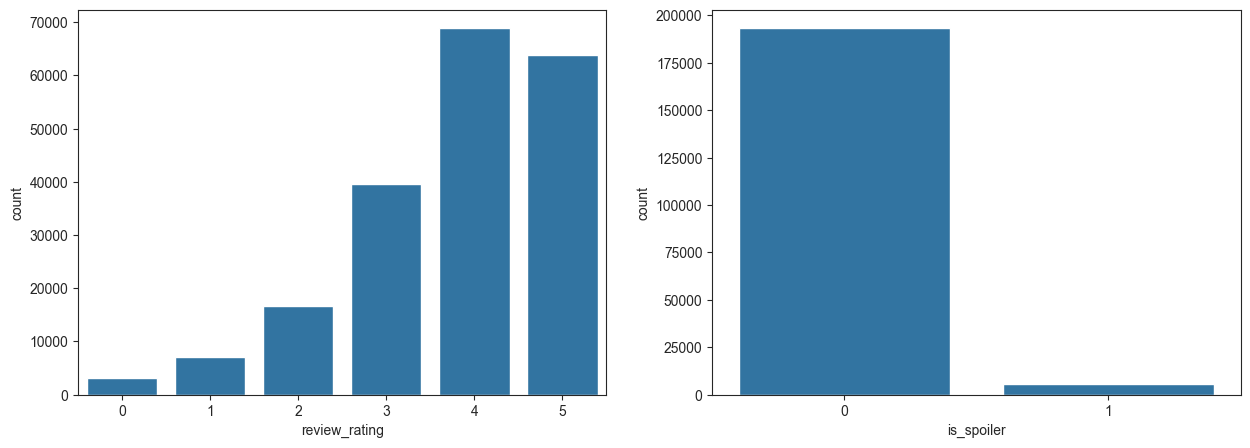

In [18]:
print(f"No. of reviews              : {df.review_id.nunique():,}")
print(f"No. of users                : {df.user_id.nunique():,}")
print(f"No. of books                : {df.book_id.nunique():,}")
print(f"No. of sentences            : {len(df):,}")
print(f"% of sentences with spoilers: {round(df.is_spoiler.sum() * 100 / len(df), 2)}%\n")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(x=df.review_rating, ax=ax[0])
sns.countplot(x=df.is_spoiler, ax=ax[1])
fig.show()

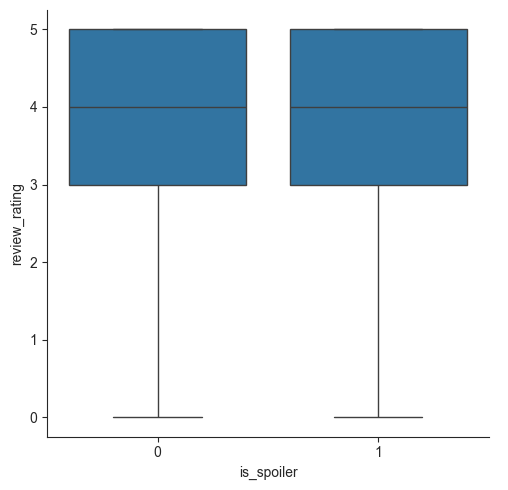

In [19]:
# is_spoiler vs. review_rating
sns.catplot(data=df, x="is_spoiler", y="review_rating", kind="box")

([], [])

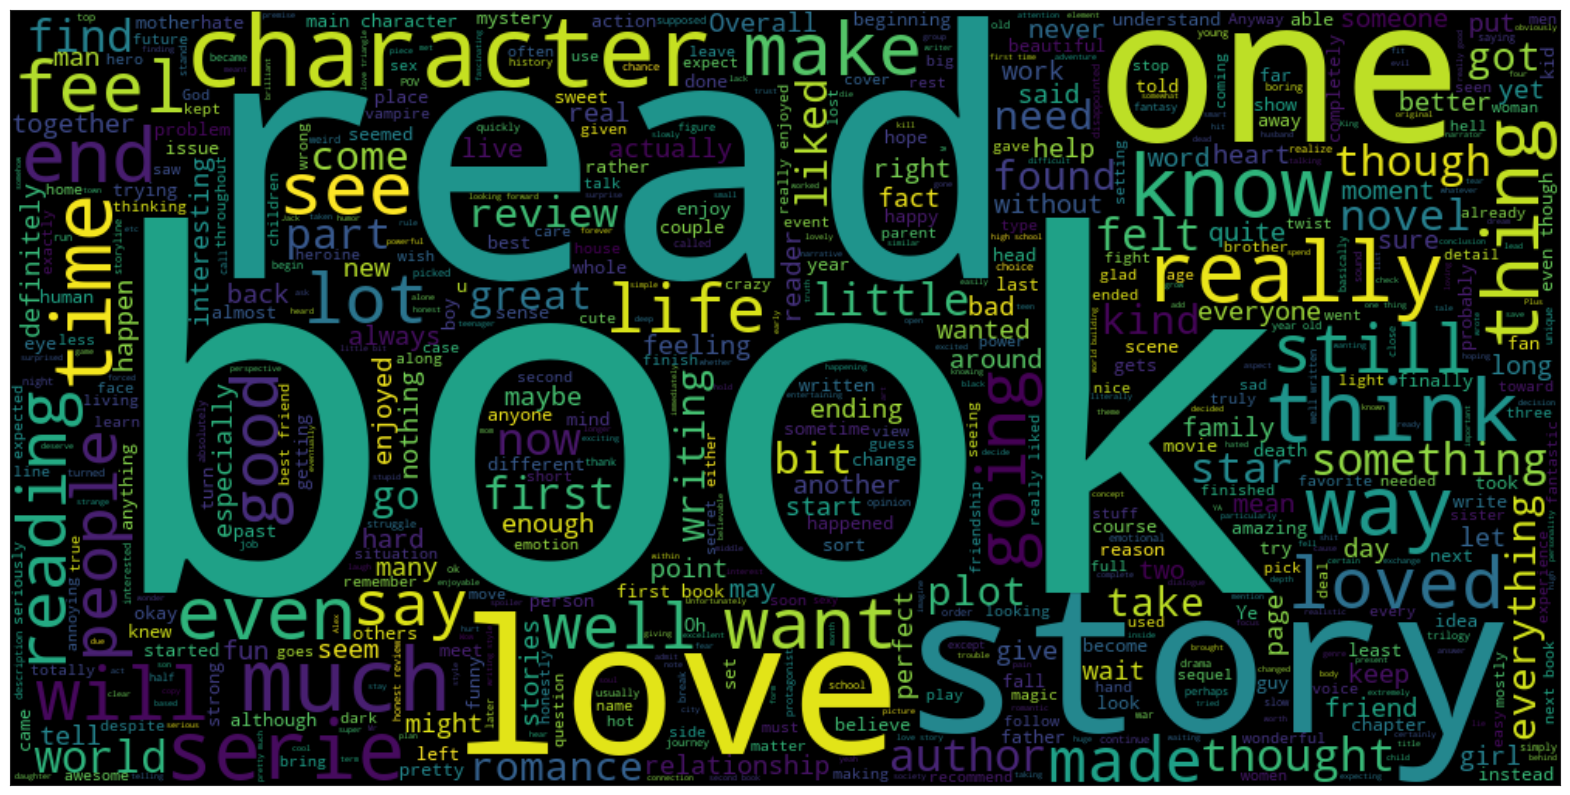

In [20]:
# Not spoiler sentences wordcloud
wc = WordCloud(max_words=2000, width=1000, height=500)
wc.generate(" ".join(df[df.is_spoiler == 0]["sentence"]))

plt.figure(figsize=(20, 20))
plt.imshow(wc, interpolation="bilinear")
plt.xticks([])
plt.yticks([])

([], [])

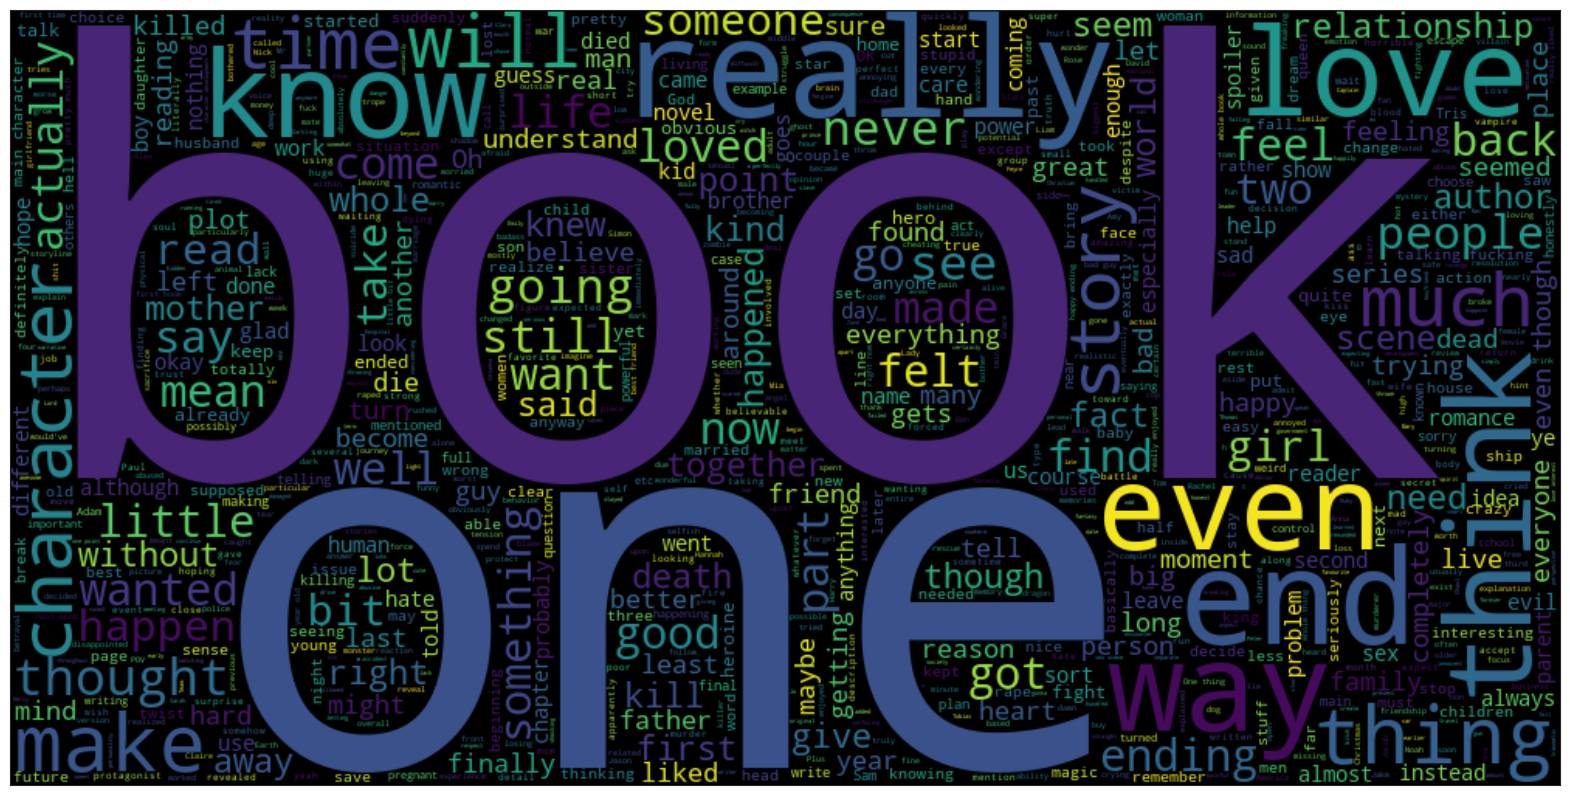

In [21]:
# Spoiler sentences wordcloud
wc = WordCloud(max_words=2000, width=1000, height=500)
wc.generate(" ".join(df[df.is_spoiler == 1]["sentence"]))

plt.figure(figsize=(20, 20))
plt.imshow(wc, interpolation="bilinear")
plt.xticks([])
plt.yticks([])

<Figure size 1000x500 with 0 Axes>

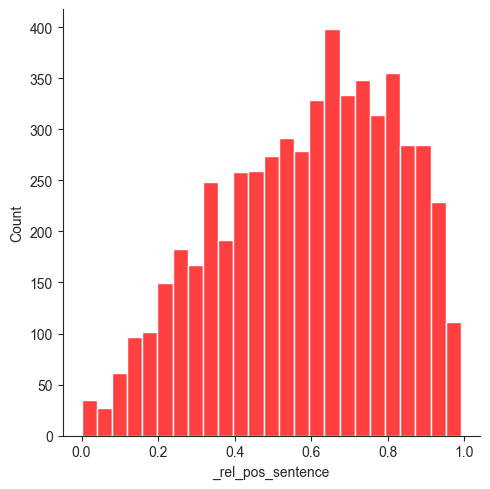

In [22]:
# Relative positions of spoilers in reviews
plt.figure(figsize=(10, 5))

sns.displot(
    data=df[df.is_spoiler == 1], x="_rel_pos_sentence", kind="hist", color="red"
)

C:\Users\yahia\AppData\Local\Temp\ipykernel_24316\2000007039.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(
C:\Users\yahia\AppData\Local\Temp\ipykernel_24316\2000007039.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(


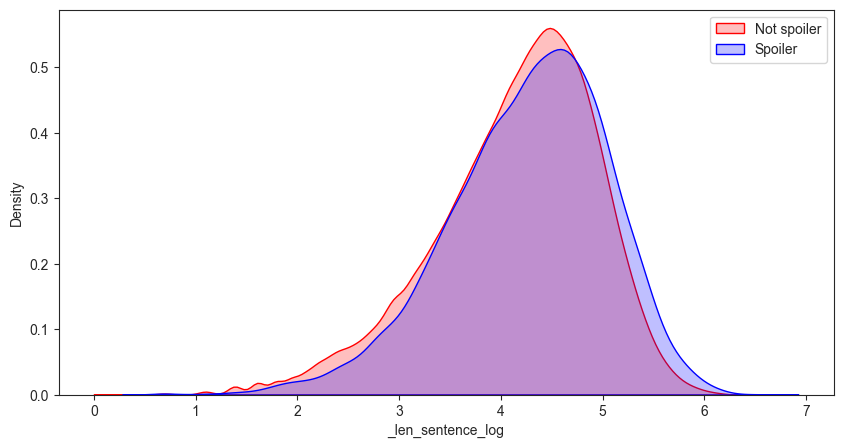

In [23]:
# is_spoiler vs. log of length of sentence
plt.figure(figsize=(10, 5))

sns.kdeplot(
    data=df[df.is_spoiler == 0], 
    x="_len_sentence_log", 
    shade=True, 
    color="red", 
    label="Not spoiler", 
    clip=[0, 2000]
)
sns.kdeplot(
    data=df[df.is_spoiler == 1], 
    x="_len_sentence_log", 
    shade=True, 
    color="blue", 
    label="Spoiler", 
    clip=[0, 2000]
)

plt.legend(loc="best")

In [24]:
X_TSNE = TSNE(
    n_components=2, random_state=42
).fit_transform(X_train_sentence_embedding[:10000])

fig = px.scatter(
    x=X_TSNE[:, 0].reshape(-1), 
    y=X_TSNE[:, 1].reshape(-1),
    color=y_train.values[:10000].reshape(-1), 
    labels={'color': 'label'},
    color_continuous_scale='Bluered_r'
)
fig.show()

# Utility Functions

We define some utility functions that are used during model training.

In [25]:
def print_metrics(model, X, y):
    """Prints performance metrics"""
    y_pred = model.predict(X) # Predicted labels
    y_pred_proba = model.predict_proba(X) # Predicted probabilities
    
    # Test accuracy
    print(f"Accuracy: {metrics.accuracy_score(y_true=y, y_pred=y_pred)}\n")
    
    # Classification report
    print(metrics.classification_report(y_true=y, y_pred=y_pred))

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

    # Confusion matrix
    cm = metrics.confusion_matrix(y_true=y, y_pred=y_pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax1, cmap=plt.cm.Blues, cbar=False)
    ax1.set(
        xlabel="Pred", ylabel="True", 
        xticklabels=[0, 1], yticklabels=[0, 1], 
        title="Confusion Matrix"
    )

    # ROC curve/AUC score
    fpr, tpr, thresholds = metrics.roc_curve(
        y_true=y, y_score=y_pred_proba[:, 1], pos_label=1
    )
    auc_score = metrics.roc_auc_score(y_true=y, y_score=y_pred_proba[:, 1])
    ax2.plot(
        fpr, tpr, color="red", label=f"ROC Curve (AUC = {round(auc_score, 3)})"
    )
    ax2.set_xlabel("False Positive Rate")
    ax2.set_ylabel("True Positive Rate")
    ax2.set_title("ROC Curve")
    ax2.legend(loc="best")

In [26]:
def print_metrics_hyper(model, X, y):
    """Truncated version of print_metrics for hyperparameter tuning"""
    y_pred = clf.predict(X) # Predicted labels
    y_pred_proba = clf.predict_proba(X) # Predicted probabilities

    accuracy = metrics.accuracy_score(y_true=y, y_pred=y_pred)
    auc_score = metrics.roc_auc_score(y_true=y, y_score=y_pred_proba[:, 1])
    precision, recall, fbeta_score, _ = metrics.precision_recall_fscore_support(
        y_true=y, y_pred=y_pred, average="binary"
    )
    print(f"accuracy: {accuracy:.3f}, auc: {auc_score:.3f}, precision: {precision:.3f}, recall: {recall:.3f}, fbeta_score: {fbeta_score:.3f}")

In [27]:
def product_dict(**kwargs):
    """Helper function for hyperparameter tuning"""
    keys = kwargs.keys()
    vals = kwargs.values()
    return [dict(zip(keys, instance)) for instance in itertools.product(*vals)] 

# Baseline

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [30]:
# Vectorize sentences
vectorizer = TfidfVectorizer(analyzer="word", max_features=20000)

X_train_sentence_tfidf = vectorizer.fit_transform(X_train.sentence.values)
X_val_sentence_tfidf = vectorizer.transform(X_val.sentence.values)
X_test_sentence_tfidf = vectorizer.transform(X_test.sentence.values)

In [31]:
# Fit logistic regression model
clf = LogisticRegression(
    penalty="l2", random_state=42, solver="lbfgs", max_iter=1000, verbose=1
)
clf.fit(X_train_sentence_tfidf, y_train.is_spoiler.values)

LogisticRegression(max_iter=1000, random_state=42, verbose=1)

Accuracy: 0.9723434343434344

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     96263
           1       0.00      0.00      0.00      2737

    accuracy                           0.97     99000
   macro avg       0.49      0.50      0.49     99000
weighted avg       0.95      0.97      0.96     99000



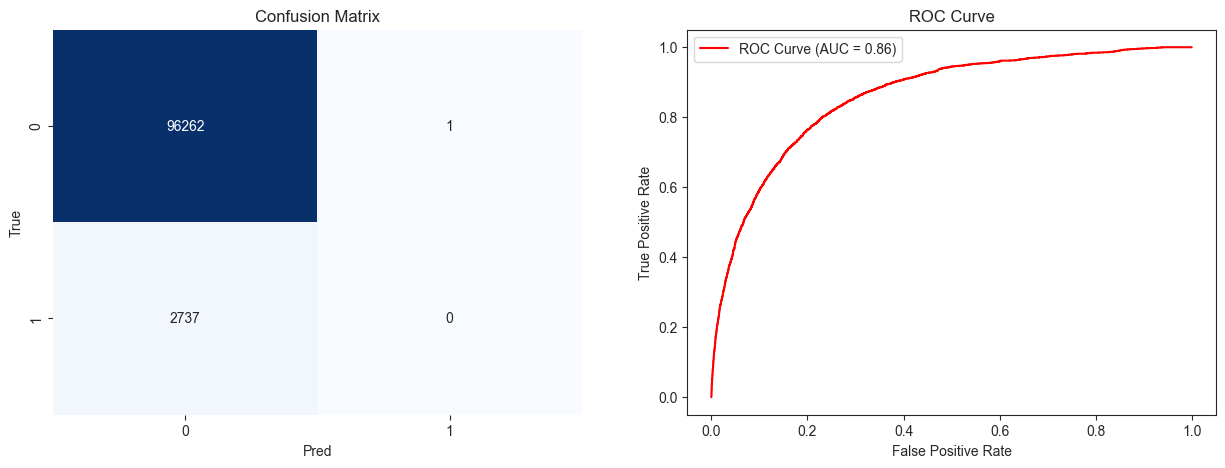

In [32]:
# Print metrics on train dataset
print_metrics(clf, X_train_sentence_tfidf, y_train.is_spoiler.values)

Accuracy: 0.97104

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     48552
           1       0.50      0.00      0.00      1448

    accuracy                           0.97     50000
   macro avg       0.74      0.50      0.49     50000
weighted avg       0.96      0.97      0.96     50000



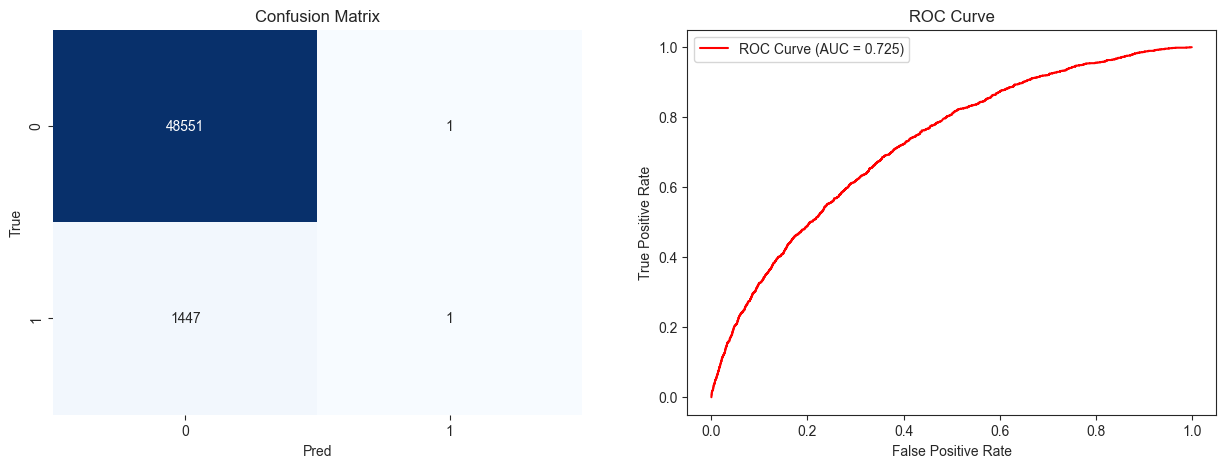

In [33]:
# Print metrics on val dataset
print_metrics(clf, X_val_sentence_tfidf, y_val.is_spoiler.values)

Accuracy: 0.97144

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     48575
           1       0.00      0.00      0.00      1425

    accuracy                           0.97     50000
   macro avg       0.49      0.50      0.49     50000
weighted avg       0.94      0.97      0.96     50000



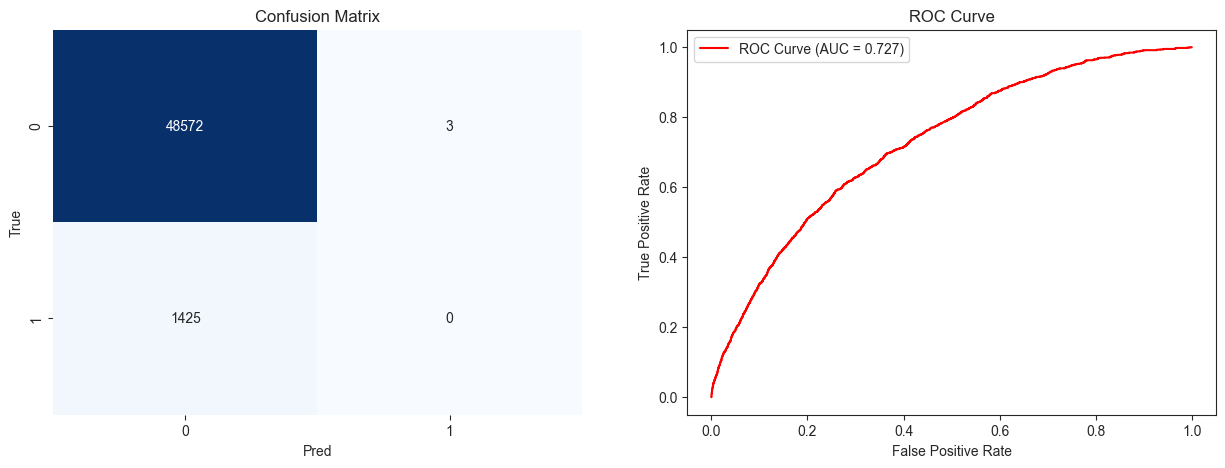

In [34]:
# Print metrics on test dataset
print_metrics(clf, X_test_sentence_tfidf, y_test.is_spoiler.values)

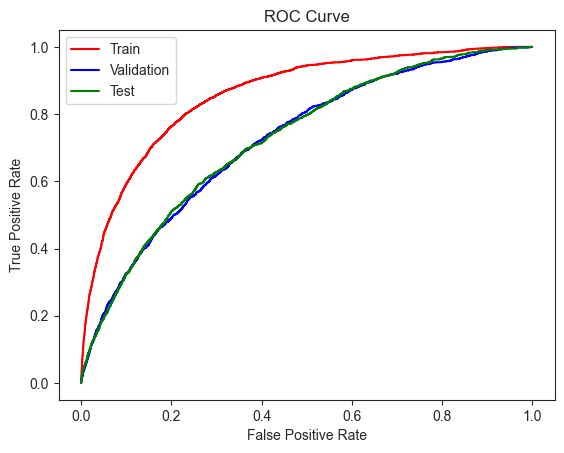

In [35]:
# Combined ROC curve for train/val/test datasets

y_pred = clf.predict(X_train_sentence_tfidf)
y_pred_proba = clf.predict_proba(X_train_sentence_tfidf)
fpr, tpr, thresholds = metrics.roc_curve(y_true=y_train.is_spoiler.values, y_score=y_pred_proba[:, 1], pos_label=1)
auc_score = metrics.roc_auc_score(y_true=y_train.is_spoiler.values, y_score=y_pred_proba[:, 1])
plt.plot(fpr, tpr, color="red", label=f"Train")

y_pred = clf.predict(X_val_sentence_tfidf)
y_pred_proba = clf.predict_proba(X_val_sentence_tfidf)
fpr, tpr, thresholds = metrics.roc_curve(y_true=y_val.is_spoiler.values, y_score=y_pred_proba[:, 1], pos_label=1)
auc_score = metrics.roc_auc_score(y_true=y_val.is_spoiler.values, y_score=y_pred_proba[:, 1])
plt.plot(fpr, tpr, color="blue", label=f"Validation")

y_pred = clf.predict(X_test_sentence_tfidf)
y_pred_proba = clf.predict_proba(X_test_sentence_tfidf)
fpr, tpr, thresholds = metrics.roc_curve(y_true=y_test.is_spoiler.values, y_score=y_pred_proba[:, 1], pos_label=1)
auc_score = metrics.roc_auc_score(y_true=y_test.is_spoiler.values, y_score=y_pred_proba[:, 1])
plt.plot(fpr, tpr, color="green", label=f"Test")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="best")

# Logistic Regression

In [36]:
# Underweight majority class + Hyperparameter tuning

class_weights = [{0: w, 1: 1} for w in [0.01, 0.05, 0.1, 0.3, 0.5, 1]]
params = (product_dict(**{"penalty": ["elasticnet"], "class_weight": class_weights, "l1_ratio": [0, 0.5, 1]}))

for param in params:
    penalty = param["penalty"]
    class_weight = param["class_weight"]
    l1_ratio = param["l1_ratio"]

    # Fit logistic regression model
    clf = LogisticRegression(penalty=penalty, class_weight=class_weight, random_state=42, solver="saga", max_iter=1000, l1_ratio=l1_ratio)
    clf.fit(X_train_values, y_train_values)

    print(f"penalty: {penalty}, class_weight: {class_weight}, l1_ratio: {l1_ratio}")
    print_metrics_hyper(clf, X_train_values, y_train_values)
    print_metrics_hyper(clf, X_val_values, y_val_values)

penalty: elasticnet, class_weight: {0: 0.01, 1: 1}, l1_ratio: 0
accuracy: 0.384, auc: 0.796, precision: 0.041, recall: 0.953, fbeta_score: 0.079
accuracy: 0.385, auc: 0.783, precision: 0.042, recall: 0.938, fbeta_score: 0.081
penalty: elasticnet, class_weight: {0: 0.01, 1: 1}, l1_ratio: 0.5
accuracy: 0.371, auc: 0.793, precision: 0.040, recall: 0.954, fbeta_score: 0.077
accuracy: 0.374, auc: 0.783, precision: 0.042, recall: 0.941, fbeta_score: 0.080
penalty: elasticnet, class_weight: {0: 0.01, 1: 1}, l1_ratio: 1
accuracy: 0.365, auc: 0.789, precision: 0.040, recall: 0.955, fbeta_score: 0.077
accuracy: 0.367, auc: 0.780, precision: 0.042, recall: 0.948, fbeta_score: 0.080
penalty: elasticnet, class_weight: {0: 0.05, 1: 1}, l1_ratio: 0
accuracy: 0.840, auc: 0.803, precision: 0.092, recall: 0.540, fbeta_score: 0.157
accuracy: 0.841, auc: 0.784, precision: 0.092, recall: 0.510, fbeta_score: 0.156
penalty: elasticnet, class_weight: {0: 0.05, 1: 1}, l1_ratio: 0.5
accuracy: 0.839, auc: 0.801,

In [37]:
# Undersample majority class + Hyperparameter tuning

params = (product_dict(**{"sampling_strategy": [0.05, 0.1, 0.3, 0.5, 1], "penalty": ["elasticnet"], "l1_ratio": [0, 0.5, 1]}))

for param in params:
    sampling_strategy = param["sampling_strategy"]
    penalty = param["penalty"]
    l1_ratio = param["l1_ratio"]

    # Undersample majority class
    X_train_rs_values, y_train_rs_values = imblearn.under_sampling.RandomUnderSampler(
        sampling_strategy=sampling_strategy,
        random_state=42
    ).fit_resample(X_train_values, y_train_values)

    # Fit logistic regression model
    clf = LogisticRegression(penalty=penalty, random_state=42, solver="saga", max_iter=1000, l1_ratio=l1_ratio)
    clf.fit(X_train_rs_values, y_train_rs_values)

    print(f"sampling_strategy: {sampling_strategy}, penalty: {penalty}, l1_ratio: {l1_ratio}")
    print_metrics_hyper(clf, X_val_values, y_val_values)

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:484: FutureWarning:

`BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: FutureWarning:

`BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.



sampling_strategy: 0.05, penalty: elasticnet, l1_ratio: 0
accuracy: 0.971, auc: 0.784, precision: 0.238, recall: 0.003, fbeta_score: 0.007


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:484: FutureWarning:

`BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: FutureWarning:

`BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.



sampling_strategy: 0.05, penalty: elasticnet, l1_ratio: 0.5
accuracy: 0.971, auc: 0.783, precision: 0.353, recall: 0.004, fbeta_score: 0.008


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:484: FutureWarning:

`BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: FutureWarning:

`BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.



...

sampling_strategy: 1, penalty: elasticnet, l1_ratio: 0
accuracy: 0.686, auc: 0.778, precision: 0.064, recall: 0.723, fbeta_score: 0.118


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:484: FutureWarning:

`BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: FutureWarning:

`BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.



sampling_strategy: 1, penalty: elasticnet, l1_ratio: 0.5
accuracy: 0.685, auc: 0.778, precision: 0.064, recall: 0.721, fbeta_score: 0.117


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:484: FutureWarning:

`BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: FutureWarning:

`BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.



sampling_strategy: 1, penalty: elasticnet, l1_ratio: 1
accuracy: 0.685, auc: 0.777, precision: 0.064, recall: 0.720, fbeta_score: 0.117


In [38]:
# Oversample minority class + Hyperparameter tuning

params = (product_dict(**{"sampling_strategy": [0.05, 0.1, 0.3, 0.5, 1], "penalty": ["elasticnet"], "l1_ratio": [0, 0.5, 1]}))

for param in params:
    sampling_strategy = param["sampling_strategy"]
    penalty = param["penalty"]
    l1_ratio = param["l1_ratio"]

    # Oversample minority class
    X_train_rs_values, y_train_rs_values = imblearn.over_sampling.SMOTE(
        sampling_strategy=sampling_strategy,
        random_state=42
    ).fit_resample(X_train_values, y_train_values)

    # Fit logistic regression model
    clf = LogisticRegression(penalty=penalty, random_state=42, solver="saga", max_iter=1000, l1_ratio=l1_ratio)
    clf.fit(X_train_rs_values, y_train_rs_values)

    print(f"sampling_strategy: {sampling_strategy}, penalty: {penalty}, l1_ratio: {l1_ratio}")
    print_metrics_hyper(clf, X_val_values, y_val_values)

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.



sampling_strategy: 0.05, penalty: elasticnet, l1_ratio: 0
accuracy: 0.971, auc: 0.780, precision: 0.212, recall: 0.005, fbeta_score: 0.009


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.



sampling_strategy: 0.05, penalty: elasticnet, l1_ratio: 0.5
accuracy: 0.971, auc: 0.780, precision: 0.219, recall: 0.005, fbeta_score: 0.009


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.



...

sampling_strategy: 1, penalty: elasticnet, l1_ratio: 0
accuracy: 0.729, auc: 0.768, precision: 0.069, recall: 0.664, fbeta_score: 0.124


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.



sampling_strategy: 1, penalty: elasticnet, l1_ratio: 0.5
accuracy: 0.729, auc: 0.767, precision: 0.068, recall: 0.662, fbeta_score: 0.124


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.



sampling_strategy: 1, penalty: elasticnet, l1_ratio: 1
accuracy: 0.729, auc: 0.767, precision: 0.068, recall: 0.660, fbeta_score: 0.124


Best performing model

In [39]:
clf = LogisticRegression(penalty="elasticnet", class_weight={0: 0.1, 1: 1}, random_state=42, solver="saga", max_iter=1000, l1_ratio=0.5)
clf.fit(X_train_values, y_train_values)

LogisticRegression(class_weight={0: 0.1, 1: 1}, l1_ratio=0.5, max_iter=1000,
                   penalty='elasticnet', random_state=42, solver='saga')

Accuracy: 0.9366767676767677

              precision    recall  f1-score   support

           0       0.98      0.96      0.97     96263
           1       0.15      0.27      0.19      2737

    accuracy                           0.94     99000
   macro avg       0.56      0.61      0.58     99000
weighted avg       0.96      0.94      0.95     99000



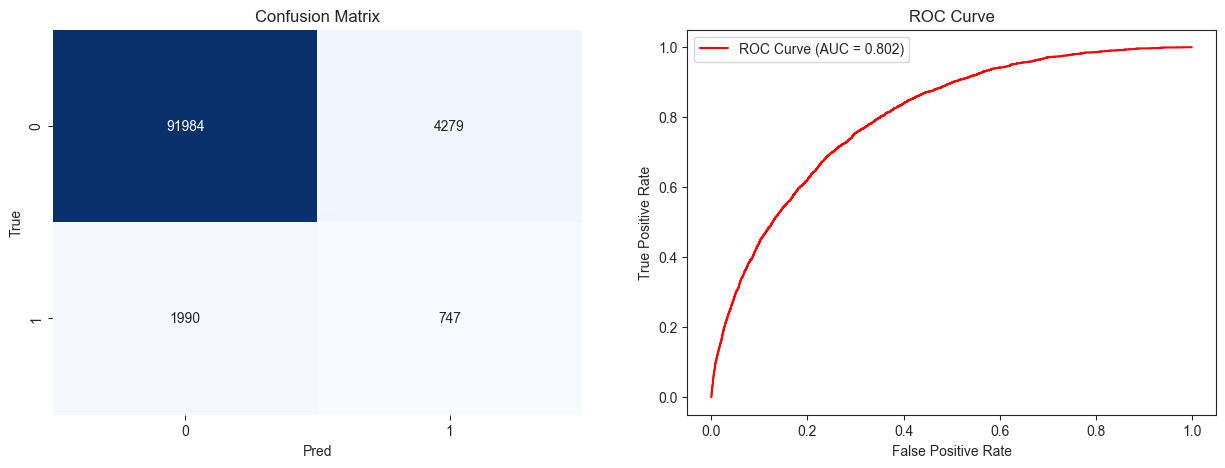

In [40]:
# Print metrics on train dataset
print_metrics(clf, X_train_values, y_train_values)

Accuracy: 0.93676

              precision    recall  f1-score   support

           0       0.98      0.96      0.97     48552
           1       0.16      0.27      0.20      1448

    accuracy                           0.94     50000
   macro avg       0.57      0.61      0.58     50000
weighted avg       0.95      0.94      0.94     50000



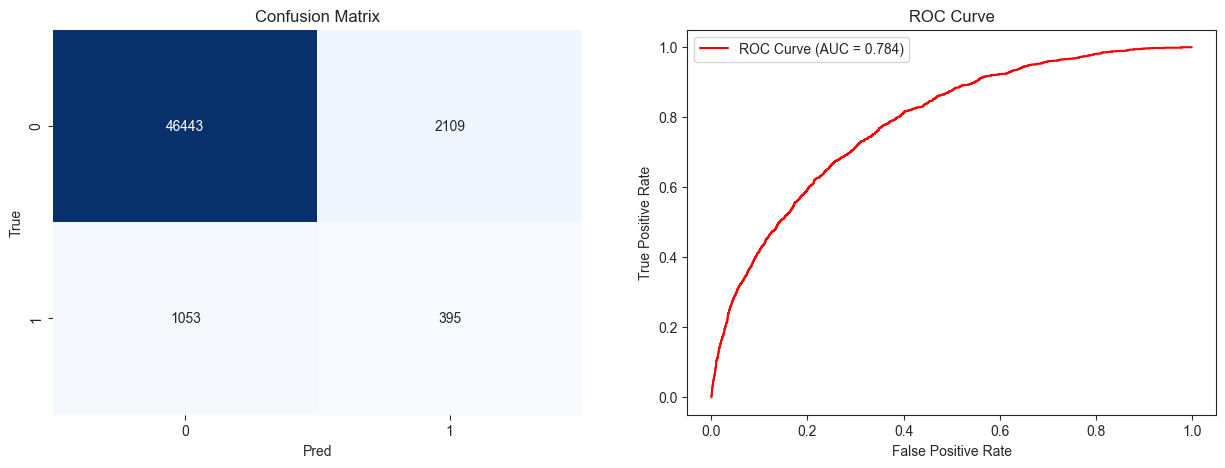

In [41]:
# Print metrics on val dataset
print_metrics(clf, X_val_values, y_val_values)

Accuracy: 0.93444

              precision    recall  f1-score   support

           0       0.98      0.95      0.97     48575
           1       0.14      0.26      0.18      1425

    accuracy                           0.93     50000
   macro avg       0.56      0.61      0.58     50000
weighted avg       0.95      0.93      0.94     50000



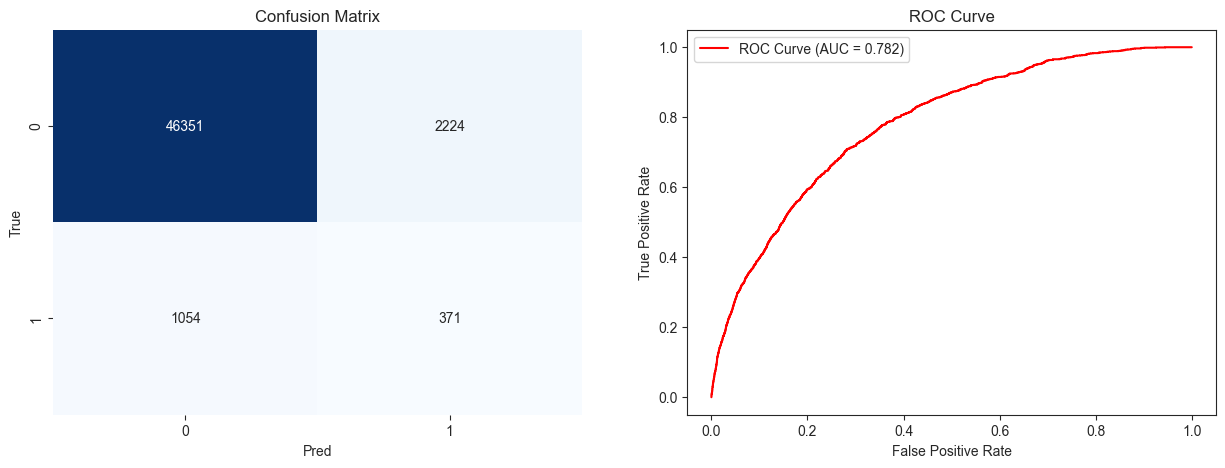

In [42]:
# Print metrics on test dataset
print_metrics(clf, X_test_values, y_test_values)

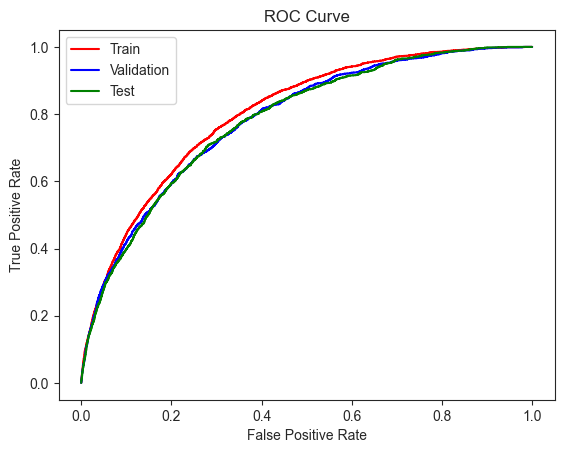

In [43]:
# Combined ROC curve for train/val/test datasets

y_pred = clf.predict(X_train_values)
y_pred_proba = clf.predict_proba(X_train_values)
fpr, tpr, thresholds = metrics.roc_curve(y_true=y_train_values, y_score=y_pred_proba[:, 1], pos_label=1)
auc_score = metrics.roc_auc_score(y_true=y_train_values, y_score=y_pred_proba[:, 1])
plt.plot(fpr, tpr, color="red", label=f"Train")

y_pred = clf.predict(X_val_values)
y_pred_proba = clf.predict_proba(X_val_values)
fpr, tpr, thresholds = metrics.roc_curve(y_true=y_val_values, y_score=y_pred_proba[:, 1], pos_label=1)
auc_score = metrics.roc_auc_score(y_true=y_val_values, y_score=y_pred_proba[:, 1])
plt.plot(fpr, tpr, color="blue", label=f"Validation")

y_pred = clf.predict(X_test_values)
y_pred_proba = clf.predict_proba(X_test_values)
fpr, tpr, thresholds = metrics.roc_curve(y_true=y_test_values, y_score=y_pred_proba[:, 1], pos_label=1)
auc_score = metrics.roc_auc_score(y_true=y_test_values, y_score=y_pred_proba[:, 1])
plt.plot(fpr, tpr, color="green", label=f"Test")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="best")

# Multi-layer Perceptron Classifier

In [44]:
params = (product_dict(**{
    'hidden_layer_sizes': [(128, 64, 32, 1)],
    'activation': ['tanh', 'relu', 'logistic'],
    'alpha': [0.0001, 0.05]
}))

for param in params:
    hidden_layer_sizes = param["hidden_layer_sizes"]
    activation = param["activation"]
    alpha = param["alpha"]

    # Fit model
    clf = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation=activation, solver="adam", alpha=alpha, random_state=42)
    clf.fit(X_train_values, y_train_values)

    print(f"hidden_layer_sizes: {hidden_layer_sizes}, activation: {activation}, alpha: {alpha}")
    print_metrics_hyper(clf, X_train_values, y_train_values)
    print_metrics_hyper(clf, X_val_values, y_val_values)

hidden_layer_sizes: (128, 64, 32, 1), activation: tanh, alpha: 0.0001
accuracy: 0.995, auc: 0.968, precision: 0.960, recall: 0.861, fbeta_score: 0.908
accuracy: 0.956, auc: 0.689, precision: 0.120, recall: 0.082, fbeta_score: 0.097
hidden_layer_sizes: (128, 64, 32, 1), activation: tanh, alpha: 0.05


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



accuracy: 0.972, auc: 0.801, precision: 0.000, recall: 0.000, fbeta_score: 0.000


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



accuracy: 0.971, auc: 0.782, precision: 0.000, recall: 0.000, fbeta_score: 0.000
hidden_layer_sizes: (128, 64, 32, 1), activation: relu, alpha: 0.0001


...

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



accuracy: 0.971, auc: 0.495, precision: 0.000, recall: 0.000, fbeta_score: 0.000
hidden_layer_sizes: (128, 64, 32, 1), activation: logistic, alpha: 0.05


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



accuracy: 0.972, auc: 0.500, precision: 0.000, recall: 0.000, fbeta_score: 0.000
accuracy: 0.971, auc: 0.500, precision: 0.000, recall: 0.000, fbeta_score: 0.000


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



In [45]:
# Undersample majority class + Hyperparameter tuning

params = (product_dict(**{
    "sampling_strategy": [0.05, 0.1, 0.3, 0.5, 1],
    'hidden_layer_sizes': [(128, 64, 32, 1)],
    'activation': ['tanh', 'relu', 'logistic'],
    'alpha': [0.0001, 0.05]
}))

for param in params:
    sampling_strategy = param["sampling_strategy"]
    hidden_layer_sizes = param["hidden_layer_sizes"]
    activation = param["activation"]
    alpha = param["alpha"]

    # Undersample majority class
    X_train_rs_values, y_train_rs_values = imblearn.under_sampling.RandomUnderSampler(
        sampling_strategy=sampling_strategy,
        random_state=42
    ).fit_resample(X_train_values, y_train_values)

    # Fit model
    clf = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation=activation, solver="adam", alpha=alpha, random_state=42)
    clf.fit(X_train_rs_values, y_train_rs_values)

    print(f"sampling_strategy: {sampling_strategy}, hidden_layer_sizes: {hidden_layer_sizes}, activation: {activation}, alpha: {alpha}")
    print_metrics_hyper(clf, X_val_values, y_val_values)

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:484: FutureWarning:

`BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: FutureWarning:

`BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.



sampling_strategy: 0.05, hidden_layer_sizes: (128, 64, 32, 1), activation: tanh, alpha: 0.0001
accuracy: 0.943, auc: 0.691, precision: 0.099, recall: 0.120, fbeta_score: 0.109


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:484: FutureWarning:

`BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: FutureWarning:

`BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.



sampling_strategy: 0.05, hidden_layer_sizes: (128, 64, 32, 1), activation: tanh, alpha: 0.05
accuracy: 0.971, auc: 0.783, precision: 0.500, recall: 0.001, fbeta_score: 0.001


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:484: FutureWarning:

`BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: FutureWarning:

`BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.



...

sampling_strategy: 1, hidden_layer_sizes: (128, 64, 32, 1), activation: relu, alpha: 0.05
accuracy: 0.029, auc: 0.500, precision: 0.029, recall: 1.000, fbeta_score: 0.056


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:484: FutureWarning:

`BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: FutureWarning:

`BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.



sampling_strategy: 1, hidden_layer_sizes: (128, 64, 32, 1), activation: logistic, alpha: 0.0001
accuracy: 0.029, auc: 0.485, precision: 0.029, recall: 1.000, fbeta_score: 0.056


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:484: FutureWarning:

`BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: FutureWarning:

`BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.



sampling_strategy: 1, hidden_layer_sizes: (128, 64, 32, 1), activation: logistic, alpha: 0.05
accuracy: 0.029, auc: 0.720, precision: 0.029, recall: 1.000, fbeta_score: 0.056


In [46]:
# Oversample minority class + Hyperparameter tuning

params = (product_dict(**{
    "sampling_strategy": [0.05, 0.1, 0.3, 0.5, 1],
    'hidden_layer_sizes': [(128, 64, 32, 1)],
    'activation': ['tanh', 'relu', 'logistic'],
    'alpha': [0.0001, 0.05]
}))

for param in params:
    sampling_strategy = param["sampling_strategy"]
    hidden_layer_sizes = param["hidden_layer_sizes"]
    activation = param["activation"]
    alpha = param["alpha"]

    # Oversample minority class
    X_train_rs_values, y_train_rs_values = imblearn.over_sampling.SMOTE(
        sampling_strategy=sampling_strategy,
        random_state=42
    ).fit_resample(X_train_values, y_train_values)

    # Fit model
    clf = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation=activation, solver="adam", alpha=alpha, random_state=42)
    clf.fit(X_train_rs_values, y_train_rs_values)

    print(f"sampling_strategy: {sampling_strategy}, hidden_layer_sizes: {hidden_layer_sizes}, activation: {activation}, alpha: {alpha}")
    print_metrics_hyper(clf, X_val_values, y_val_values)

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.



sampling_strategy: 0.05, hidden_layer_sizes: (128, 64, 32, 1), activation: tanh, alpha: 0.0001
accuracy: 0.952, auc: 0.691, precision: 0.101, recall: 0.082, fbeta_score: 0.091


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.



sampling_strategy: 0.05, hidden_layer_sizes: (128, 64, 32, 1), activation: tanh, alpha: 0.05


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.



...

sampling_strategy: 1, hidden_layer_sizes: (128, 64, 32, 1), activation: relu, alpha: 0.05
accuracy: 0.029, auc: 0.500, precision: 0.029, recall: 1.000, fbeta_score: 0.056


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



sampling_strategy: 1, hidden_layer_sizes: (128, 64, 32, 1), activation: logistic, alpha: 0.0001
accuracy: 0.936, auc: 0.690, precision: 0.088, recall: 0.128, fbeta_score: 0.105


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.



sampling_strategy: 1, hidden_layer_sizes: (128, 64, 32, 1), activation: logistic, alpha: 0.05
accuracy: 0.029, auc: 0.482, precision: 0.029, recall: 1.000, fbeta_score: 0.056


Best performing model

In [47]:
X_train_rs_values, y_train_rs_values = imblearn.over_sampling.SMOTE(
    sampling_strategy=0.3,
    random_state=42
).fit_resample(X_train_values, y_train_values)

clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32, 1), activation="tanh", solver="adam", alpha=0.05, random_state=42)
clf.fit(X_train_rs_values, y_train_rs_values)

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



MLPClassifier(activation='tanh', alpha=0.05,
              hidden_layer_sizes=(128, 64, 32, 1), random_state=42)

Accuracy: 0.9728181818181818

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     96263
           1       0.51      0.60      0.55      2737

    accuracy                           0.97     99000
   macro avg       0.75      0.79      0.77     99000
weighted avg       0.98      0.97      0.97     99000



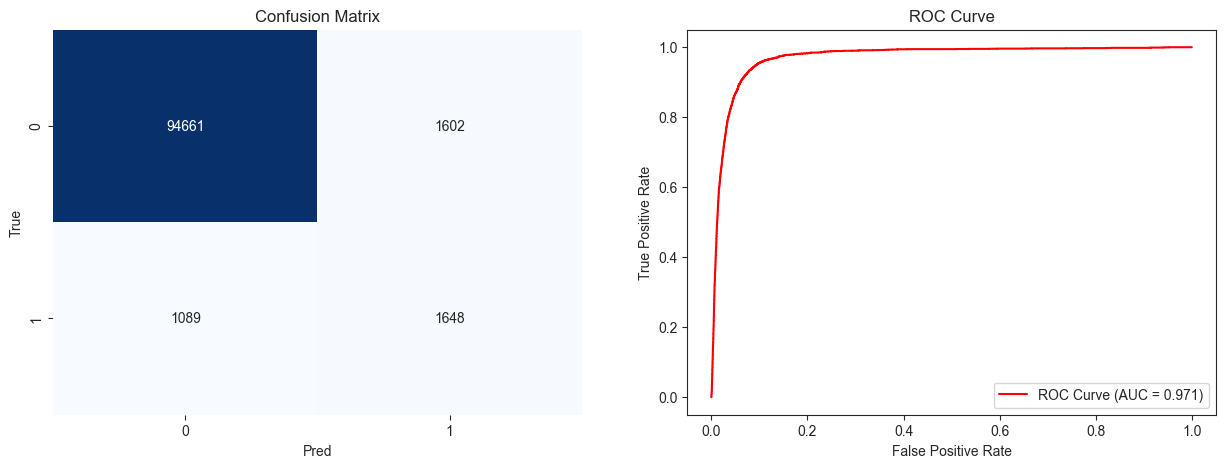

In [48]:
# Print metrics on train dataset
print_metrics(clf, X_train_values, y_train_values)

Accuracy: 0.935

              precision    recall  f1-score   support

           0       0.97      0.96      0.97     48552
           1       0.08      0.12      0.10      1448

    accuracy                           0.94     50000
   macro avg       0.53      0.54      0.53     50000
weighted avg       0.95      0.94      0.94     50000



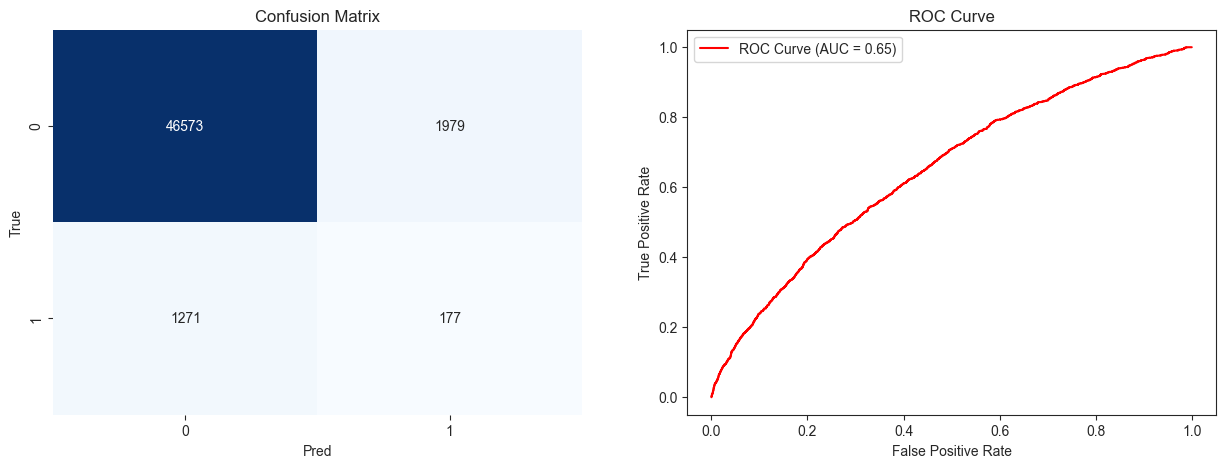

In [49]:
# Print metrics on val dataset
print_metrics(clf, X_val_values, y_val_values)

Accuracy: 0.93548

              precision    recall  f1-score   support

           0       0.97      0.96      0.97     48575
           1       0.09      0.13      0.10      1425

    accuracy                           0.94     50000
   macro avg       0.53      0.55      0.54     50000
weighted avg       0.95      0.94      0.94     50000



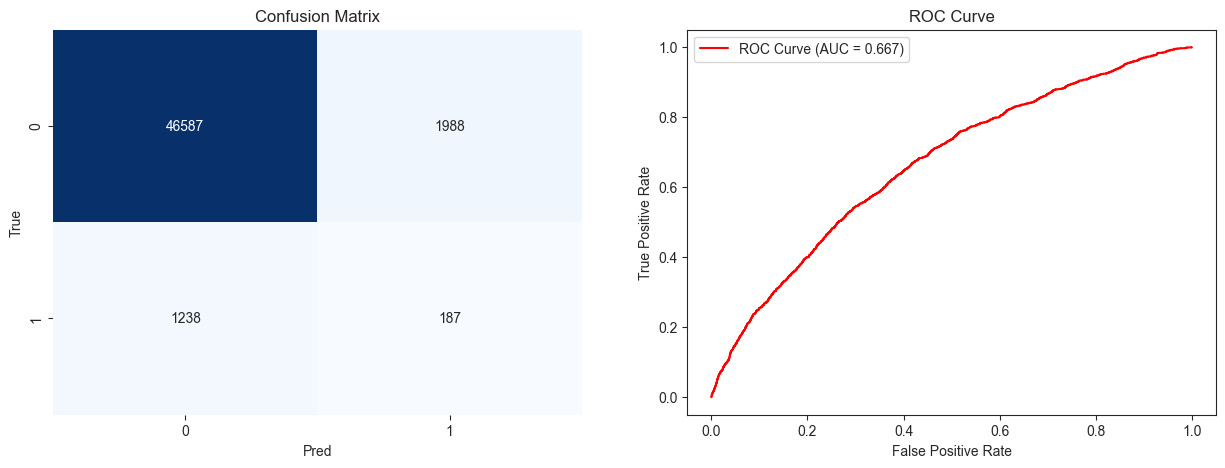

In [50]:
# Print metrics on test dataset
print_metrics(clf, X_test_values, y_test_values)

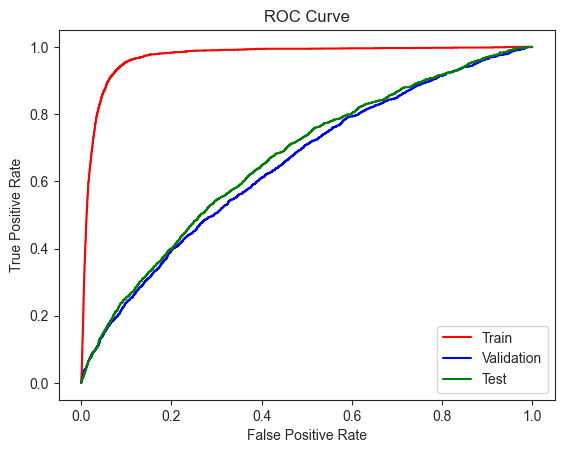

In [51]:
# Combined ROC curve for train/val/test datasets

y_pred = clf.predict(X_train_values)
y_pred_proba = clf.predict_proba(X_train_values)
fpr, tpr, thresholds = metrics.roc_curve(y_true=y_train_values, y_score=y_pred_proba[:, 1], pos_label=1)
auc_score = metrics.roc_auc_score(y_true=y_train_values, y_score=y_pred_proba[:, 1])
plt.plot(fpr, tpr, color="red", label=f"Train")

y_pred = clf.predict(X_val_values)
y_pred_proba = clf.predict_proba(X_val_values)
fpr, tpr, thresholds = metrics.roc_curve(y_true=y_val_values, y_score=y_pred_proba[:, 1], pos_label=1)
auc_score = metrics.roc_auc_score(y_true=y_val_values, y_score=y_pred_proba[:, 1])
plt.plot(fpr, tpr, color="blue", label=f"Validation")

y_pred = clf.predict(X_test_values)
y_pred_proba = clf.predict_proba(X_test_values)
fpr, tpr, thresholds = metrics.roc_curve(y_true=y_test_values, y_score=y_pred_proba[:, 1], pos_label=1)
auc_score = metrics.roc_auc_score(y_true=y_test_values, y_score=y_pred_proba[:, 1])
plt.plot(fpr, tpr, color="green", label=f"Test")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="best")

# Random Forest Classifier

In [52]:
# Underweight majority class + Hyperparameter tuning

params = (product_dict(**{
    "n_estimators": [100, 150],
    "max_depth": [5, 7],
    "min_samples_leaf": [1, 5],
    "class_weight": [{0: w, 1: 1} for w in [0.01, 0.05, 0.1, 0.3, 0.5, 1]]
}))

for param in params:
    n_estimators = param["n_estimators"]
    max_depth = param["max_depth"]
    min_samples_leaf = param["min_samples_leaf"]
    class_weight = param["class_weight"]
    
    # Fit model
    clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=42, class_weight=class_weight)
    clf.fit(X_train_values, y_train_values)

    print(f"n_estimators: {n_estimators}, max_depth: {max_depth}, min_samples_leaf: {min_samples_leaf}, class_weight: {class_weight}")
    print_metrics_hyper(clf, X_train_values, y_train_values)
    print_metrics_hyper(clf, X_val_values, y_val_values)

n_estimators: 100, max_depth: 5, min_samples_leaf: 1, class_weight: {0: 0.01, 1: 1}
accuracy: 0.182, auc: 0.827, precision: 0.033, recall: 0.996, fbeta_score: 0.063
accuracy: 0.179, auc: 0.756, precision: 0.034, recall: 0.983, fbeta_score: 0.065
n_estimators: 100, max_depth: 5, min_samples_leaf: 1, class_weight: {0: 0.05, 1: 1}
accuracy: 0.966, auc: 0.819, precision: 0.257, recall: 0.121, fbeta_score: 0.165
accuracy: 0.963, auc: 0.757, precision: 0.169, recall: 0.073, fbeta_score: 0.102
n_estimators: 100, max_depth: 5, min_samples_leaf: 1, class_weight: {0: 0.1, 1: 1}


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



accuracy: 0.972, auc: 0.823, precision: 0.000, recall: 0.000, fbeta_score: 0.000


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



accuracy: 0.971, auc: 0.754, precision: 0.000, recall: 0.000, fbeta_score: 0.000
n_estimators: 100, max_depth: 5, min_samples_leaf: 1, class_weight: {0: 0.3, 1: 1}


...

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



accuracy: 0.971, auc: 0.758, precision: 0.000, recall: 0.000, fbeta_score: 0.000
n_estimators: 150, max_depth: 7, min_samples_leaf: 5, class_weight: {0: 1, 1: 1}


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



accuracy: 0.972, auc: 0.921, precision: 0.000, recall: 0.000, fbeta_score: 0.000
accuracy: 0.971, auc: 0.757, precision: 0.000, recall: 0.000, fbeta_score: 0.000


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



In [53]:
# Undersample majority class + Hyperparameter tuning

params = (product_dict(**{
    "n_estimators": [100, 150],
    "max_depth": [5, 7],
    "min_samples_leaf": [1, 5],
    "sampling_strategy": [0.05, 0.1, 0.3, 0.5, 1]
}))

for param in params:
    sampling_strategy = param["sampling_strategy"]
    n_estimators = param["n_estimators"]
    max_depth = param["max_depth"]
    min_samples_leaf = param["min_samples_leaf"]
    
    # Undersample majority class
    X_train_rs_values, y_train_rs_values = imblearn.under_sampling.RandomUnderSampler(
        sampling_strategy=sampling_strategy,
        random_state=42
    ).fit_resample(X_train_values, y_train_values)
    
    # Fit model
    clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=42)
    clf.fit(X_train_rs_values, y_train_rs_values)

    print(f"sampling_strategy: {sampling_strategy}, n_estimators: {n_estimators}, max_depth: {max_depth}, min_samples_leaf: {min_samples_leaf}")
    print_metrics_hyper(clf, X_val_values, y_val_values)

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:484: FutureWarning:

`BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: FutureWarning:

`BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.



sampling_strategy: 0.05, n_estimators: 100, max_depth: 5, min_samples_leaf: 1


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:484: FutureWarning:

`BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: FutureWarning:

`BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.



accuracy: 0.971, auc: 0.752, precision: 0.000, recall: 0.000, fbeta_score: 0.000
sampling_strategy: 0.1, n_estimators: 100, max_depth: 5, min_samples_leaf: 1


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:484: FutureWarning:

`BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: FutureWarning:

`BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.



...

accuracy: 0.971, auc: 0.762, precision: 0.000, recall: 0.000, fbeta_score: 0.000
sampling_strategy: 0.3, n_estimators: 150, max_depth: 7, min_samples_leaf: 5
accuracy: 0.971, auc: 0.763, precision: 0.500, recall: 0.001, fbeta_score: 0.001


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:484: FutureWarning:

`BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: FutureWarning:

`BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.



sampling_strategy: 0.5, n_estimators: 150, max_depth: 7, min_samples_leaf: 5
accuracy: 0.957, auc: 0.762, precision: 0.152, recall: 0.106, fbeta_score: 0.125


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:484: FutureWarning:

`BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: FutureWarning:

`BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.



sampling_strategy: 1, n_estimators: 150, max_depth: 7, min_samples_leaf: 5
accuracy: 0.621, auc: 0.765, precision: 0.057, recall: 0.773, fbeta_score: 0.106


In [54]:
# Oversample minority class + Hyperparameter tuning

params = (product_dict(**{
    "n_estimators": [100, 150],
    "max_depth": [5, 7],
    "min_samples_leaf": [1, 5],
    "sampling_strategy": [0.05, 0.1, 0.3, 0.5, 1]
}))

for param in params:
    sampling_strategy = param["sampling_strategy"]
    n_estimators = param["n_estimators"]
    max_depth = param["max_depth"]
    min_samples_leaf = param["min_samples_leaf"]
    
    # Oversample minority class
    X_train_rs_values, y_train_rs_values = imblearn.over_sampling.SMOTE(
        sampling_strategy=sampling_strategy,
        random_state=42
    ).fit_resample(X_train_values, y_train_values)
    
    # Fit model
    clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=42)
    clf.fit(X_train_rs_values, y_train_rs_values)

    print(f"sampling_strategy: {sampling_strategy}, n_estimators: {n_estimators}, max_depth: {max_depth}, min_samples_leaf: {min_samples_leaf}")
    print_metrics_hyper(clf, X_val_values, y_val_values)

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.



sampling_strategy: 0.05, n_estimators: 100, max_depth: 5, min_samples_leaf: 1


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.



accuracy: 0.971, auc: 0.755, precision: 0.000, recall: 0.000, fbeta_score: 0.000
sampling_strategy: 0.1, n_estimators: 100, max_depth: 5, min_samples_leaf: 1


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.



...

accuracy: 0.971, auc: 0.758, precision: 0.000, recall: 0.000, fbeta_score: 0.000
sampling_strategy: 0.3, n_estimators: 150, max_depth: 7, min_samples_leaf: 5
accuracy: 0.971, auc: 0.759, precision: 0.667, recall: 0.001, fbeta_score: 0.003


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.



sampling_strategy: 0.5, n_estimators: 150, max_depth: 7, min_samples_leaf: 5
accuracy: 0.955, auc: 0.758, precision: 0.139, recall: 0.108, fbeta_score: 0.122


c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.



sampling_strategy: 1, n_estimators: 150, max_depth: 7, min_samples_leaf: 5
accuracy: 0.736, auc: 0.756, precision: 0.066, recall: 0.616, fbeta_score: 0.119


Best performing model

In [55]:
clf = RandomForestClassifier(n_estimators=150, max_depth=7, min_samples_leaf=1, random_state=42, class_weight={0: 0.05, 1: 1})
clf.fit(X_train_values, y_train_values)

RandomForestClassifier(class_weight={0: 0.05, 1: 1}, max_depth=7,
                       n_estimators=150, random_state=42)

Accuracy: 0.9702525252525253

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     96263
           1       0.44      0.27      0.34      2737

    accuracy                           0.97     99000
   macro avg       0.71      0.63      0.66     99000
weighted avg       0.96      0.97      0.97     99000



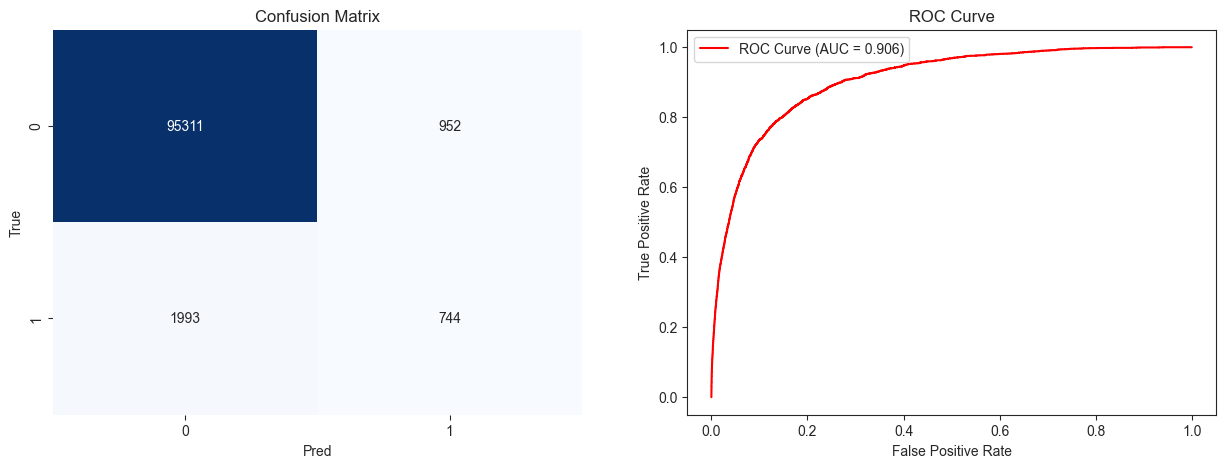

In [56]:
# Print metrics on train dataset
print_metrics(clf, X_train_values, y_train_values)

Accuracy: 0.9626

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     48552
           1       0.17      0.08      0.10      1448

    accuracy                           0.96     50000
   macro avg       0.57      0.53      0.54     50000
weighted avg       0.95      0.96      0.96     50000



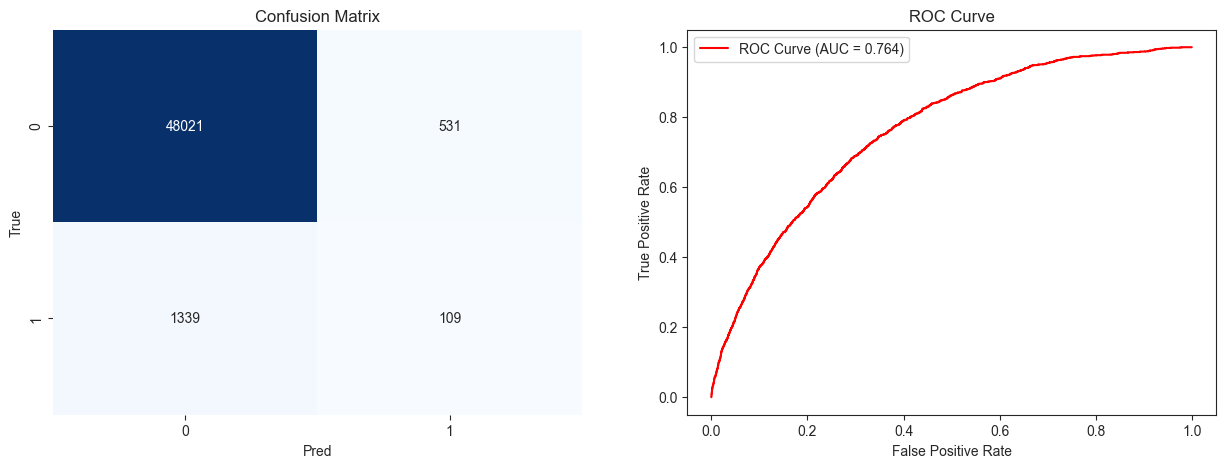

In [57]:
# Print metrics on val dataset
print_metrics(clf, X_val_values, y_val_values)

Accuracy: 0.962

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     48575
           1       0.15      0.07      0.10      1425

    accuracy                           0.96     50000
   macro avg       0.56      0.53      0.54     50000
weighted avg       0.95      0.96      0.96     50000



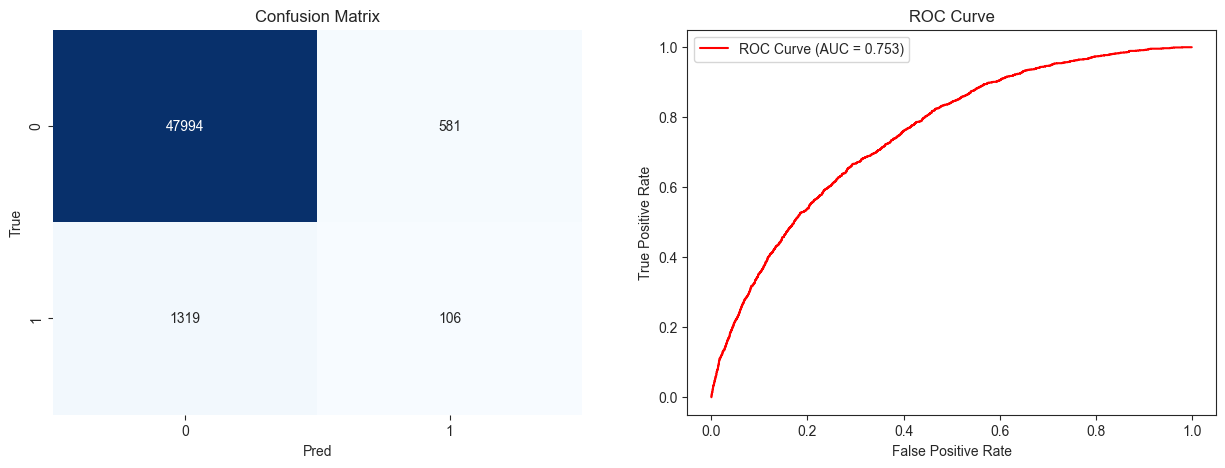

In [58]:
# Print metrics on test dataset
print_metrics(clf, X_test_values, y_test_values)

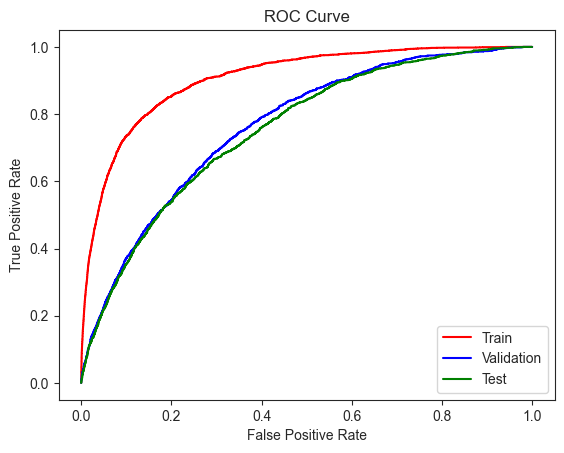

In [59]:
# Combined ROC curve for train/val/test datasets

y_pred = clf.predict(X_train_values)
y_pred_proba = clf.predict_proba(X_train_values)
fpr, tpr, thresholds = metrics.roc_curve(y_true=y_train_values, y_score=y_pred_proba[:, 1], pos_label=1)
auc_score = metrics.roc_auc_score(y_true=y_train_values, y_score=y_pred_proba[:, 1])
plt.plot(fpr, tpr, color="red", label=f"Train")

y_pred = clf.predict(X_val_values)
y_pred_proba = clf.predict_proba(X_val_values)
fpr, tpr, thresholds = metrics.roc_curve(y_true=y_val_values, y_score=y_pred_proba[:, 1], pos_label=1)
auc_score = metrics.roc_auc_score(y_true=y_val_values, y_score=y_pred_proba[:, 1])
plt.plot(fpr, tpr, color="blue", label=f"Validation")

y_pred = clf.predict(X_test_values)
y_pred_proba = clf.predict_proba(X_test_values)
fpr, tpr, thresholds = metrics.roc_curve(y_true=y_test_values, y_score=y_pred_proba[:, 1], pos_label=1)
auc_score = metrics.roc_auc_score(y_true=y_test_values, y_score=y_pred_proba[:, 1])
plt.plot(fpr, tpr, color="green", label=f"Test")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="best")

# Fine-tuning DistilBERT

In [60]:
# Switch to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [61]:
# Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-cased')

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [63]:
def create_data_loader(X, y):
    input_ids = []
    attention_masks = []

    for sentence in tqdm(X.sentence):
        encoded_dict = tokenizer(
            text=sentence,
            padding="max_length",
            truncation=True,
            max_length=128,
            return_tensors="pt",
            return_token_type_ids=False,
            return_attention_mask=True
        )
        input_ids.append(encoded_dict["input_ids"])
        attention_masks.append(encoded_dict["attention_mask"])

    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    _rel_pos_sentences = torch.Tensor(X._rel_pos_sentence.to_numpy().astype(np.float64))
    _len_sentence_logs = torch.Tensor(X._len_sentence_log.to_numpy().astype(np.float64))
    labels = torch.LongTensor(y.is_spoiler.to_numpy())
    dataset = TensorDataset(input_ids, attention_masks, _rel_pos_sentences, _len_sentence_logs, labels)
    data_loader = DataLoader(
        dataset,
        sampler=RandomSampler(dataset),
        batch_size=8
    )

    return data_loader

train_dataloader = create_data_loader(X_train, y_train)
val_dataloader = create_data_loader(X_val, y_val)
test_dataloader = create_data_loader(X_test, y_test)

100%|██████████| 50000/50000 [00:11<00:00, 4379.20it/s]


In [64]:
# Load DistilBERT
distilBERT = AutoModel.from_pretrained("distilbert-base-cased")

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [65]:
# Freeze DistilBERT parameters
for param in distilBERT.parameters():
    param.requires_grad = False

# # Unfreeze DistilBERT parameters
# for param in distilBERT.parameters():
#     param.requires_grad = True

The model we have used is shown below. We have given a walkthrough of the same in the report in the Methods section.

In [67]:
class DistilBERTModified(nn.Module):
    def __init__(self):
        super().__init__()
        self.gamma = 2 # For focal loss
        self.alpha = 0.25 # For focal loss
        self.eps = 1e-6 # For focal loss
        self.distilbert = distilBERT
        self.dropout1 = nn.Dropout(p=0.1)
        self.dense1 = nn.Linear(in_features=770, out_features=770)
        self.relu1 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.1)
        self.dense2 = nn.Linear(in_features=770, out_features=256)
        self.relu2 = nn.ReLU()
        self.dropout3 = nn.Dropout(p=0.1)
        self.dense3 = nn.Linear(in_features=256, out_features=32)
        self.relu3 = nn.ReLU()
        self.dropout4 = nn.Dropout(p=0.1)
        self.dense4 = nn.Linear(in_features=32, out_features=1)

    def forward(self, input_ids, attention_mask, _rel_pos_sentences, _len_sentence_logs, labels=None):
        output = self.distilbert(input_ids, attention_mask=attention_mask)
        output = output[0] # torch.Size([32, 128, 768])
        output = output[:, 0] # torch.Size([32, 768])
        output = torch.hstack((output, _rel_pos_sentences.reshape(-1, 1), _len_sentence_logs.reshape(-1, 1))) # torch.Size([32, 770])
        output = self.relu1(self.dense1(self.dropout1(output))) # torch.Size([32, 770])
        output = self.relu2(self.dense2(self.dropout2(output))) # torch.Size([32, 256])
        output = self.relu3(self.dense3(self.dropout3(output))) # torch.Size([32, 32])
        logits = self.dense4(self.dropout4(output)) # torch.Size([32, 1])

        loss = None
        if labels is not None:
            # BCE loss
            # loss_fct = BCEWithLogitsLoss()
            # loss = loss_fct(logits.view(-1), labels.view(-1).float())            # 
            
            # Weighted BCE loss
            # loss_fct = BCEWithLogitsLoss(pos_weight=torch.Tensor([32.0]).to(device))
            # loss = loss_fct(logits.view(-1), labels.view(-1).float())

            # Focal loss
            probs = torch.sigmoid(logits).view(-1)
            labels = labels.view(-1)
            probs_0 = torch.clamp(probs[labels == 0], min=self.eps, max=1-self.eps)
            probs_1 = torch.clamp(probs[labels == 1], min=self.eps, max=1-self.eps)
            loss_0 = -((1 - self.alpha) * torch.pow(probs_0, self.gamma) * torch.log(1 - probs_0)).mean() if len(probs_0) > 0 else 0
            loss_1 = -(self.alpha * torch.pow(1 - probs_1, self.gamma) * torch.log(probs_1)).mean() if len(probs_1) > 0 else 0
            loss = loss_0 + loss_1

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=None,
            attentions=None
        )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = DistilBERTModified()
model.to(device)

Using device: cpu


DistilBERTModified(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1

In [68]:
# Optimizer + Scheduler
epochs = 5
total_steps = len(train_dataloader) * epochs
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

In [69]:
# Training + Validation loop

# Fix seed for reproducibility
seed_val = 42
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

statistics = []

for i in range(epochs):
    print(f"========== Epoch {i + 1} / {epochs} ==========")
    model.train()
    train_loss = 0

    for step, batch in enumerate(train_dataloader):
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        _rel_pos_sentences = batch[2].to(device)
        _len_sentence_logs = batch[3].to(device)
        labels = batch[4].to(device)    

        model.zero_grad()        
        
        output = model(
            input_ids, 
            attention_mask=attention_mask,
            _rel_pos_sentences=_rel_pos_sentences,
            _len_sentence_logs=_len_sentence_logs,
            labels=labels
        )
        
        loss, logits = output[0], output[1]
        train_loss += loss.item()
        loss.backward()

        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

    avg_train_loss = train_loss / len(train_dataloader)            

    model.eval()
    eval_loss = 0

    for batch in val_dataloader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        _rel_pos_sentences = batch[2].to(device)
        _len_sentence_logs = batch[3].to(device)
        labels = batch[4].to(device) 
        
        with torch.no_grad():        
            output = model(
                input_ids,
                attention_mask=attention_mask,
                _rel_pos_sentences=_rel_pos_sentences,
                _len_sentence_logs=_len_sentence_logs,
                labels=labels
            )
            loss, logits = output[0], output[1]
        eval_loss += loss.item()

    avg_val_loss = eval_loss / len(val_dataloader)

    statistics.append(
        {
            "epoch": i + 1,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
        }
    )

========== Epoch 1 / 5 ==========
========== Epoch 2 / 5 ==========
========== Epoch 3 / 5 ==========
========== Epoch 4 / 5 ==========
========== Epoch 5 / 5 ==========


In [70]:
# Save model locally
torch.save(model.state_dict(), "checkpoint.pt")
print("Model saved as checkpoint.pt")


Model saved as checkpoint.pt


In [71]:
# Load model from a saved checkpoint file to gather metrics
loaded_model = DistilBERTModified()
loaded_model.load_state_dict(torch.load("checkpoint.pt", map_location=device))
loaded_model.to(device)


DistilBERTModified(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1

Accuracy: 0.9723535353535353

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     96263
           1       0.00      0.00      0.00      2737

    accuracy                           0.97     99000
   macro avg       0.49      0.50      0.49     99000
weighted avg       0.95      0.97      0.96     99000



c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



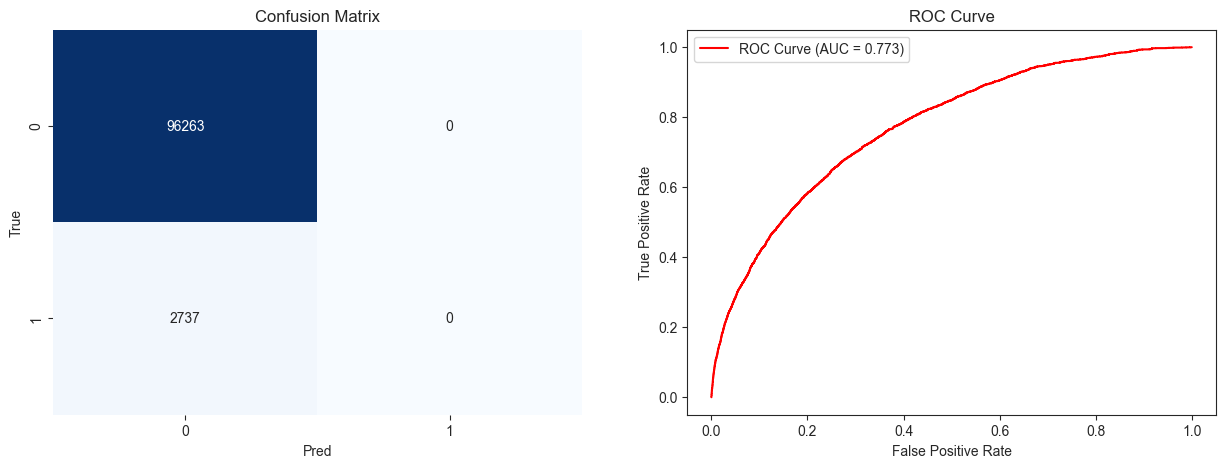

In [72]:
loaded_model.eval()

true_labels = []
predictions = []

for batch in train_dataloader:
    batch = tuple(t.to(device) for t in batch)
    input_ids, attention_mask, _rel_pos_sentences, _len_sentence_logs, labels = batch

    with torch.no_grad():
        outputs = loaded_model(input_ids, attention_mask, _rel_pos_sentences, _len_sentence_logs, labels=None)

    logits = outputs["logits"]
    logits = logits.detach().cpu().numpy()
    predictions.append(logits)

    labels = labels.to("cpu").numpy()
    true_labels.append(labels)

train_y_true = []
train_y_pred = []
train_y_score = []

for i in range(len(predictions)):
    train_y_true.extend(list(true_labels[i]))
    train_y_pred.extend(((torch.sigmoid(torch.Tensor(predictions[i])) > 0.5) * 1).view(-1).tolist())
    train_y_score.extend(torch.sigmoid(torch.Tensor(predictions[i])).view(-1).tolist())

# Accuracy
print(f"Accuracy: {metrics.accuracy_score(y_true=train_y_true, y_pred=train_y_pred)}\n")

# Classification report
print(metrics.classification_report(y_true=train_y_true, y_pred=train_y_pred))

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Confusion matrix
cm = metrics.confusion_matrix(y_true=train_y_true, y_pred=train_y_pred)
sns.heatmap(cm, annot=True, fmt="d", ax=ax1, cmap=plt.cm.Blues, cbar=False)
ax1.set(xlabel="Pred", ylabel="True", xticklabels=[0, 1], yticklabels=[0, 1], title="Confusion Matrix")

# ROC curve/AUC score
fpr, tpr, thresholds = metrics.roc_curve(y_true=train_y_true, y_score=train_y_score, pos_label=1)
auc_score = metrics.roc_auc_score(y_true=train_y_true, y_score=train_y_score)
ax2.plot(fpr, tpr, color="red", label=f"ROC Curve (AUC = {round(auc_score, 3)})")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve")
ax2.legend(loc="best")

Accuracy: 0.97104

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     48552
           1       0.00      0.00      0.00      1448

    accuracy                           0.97     50000
   macro avg       0.49      0.50      0.49     50000
weighted avg       0.94      0.97      0.96     50000



c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



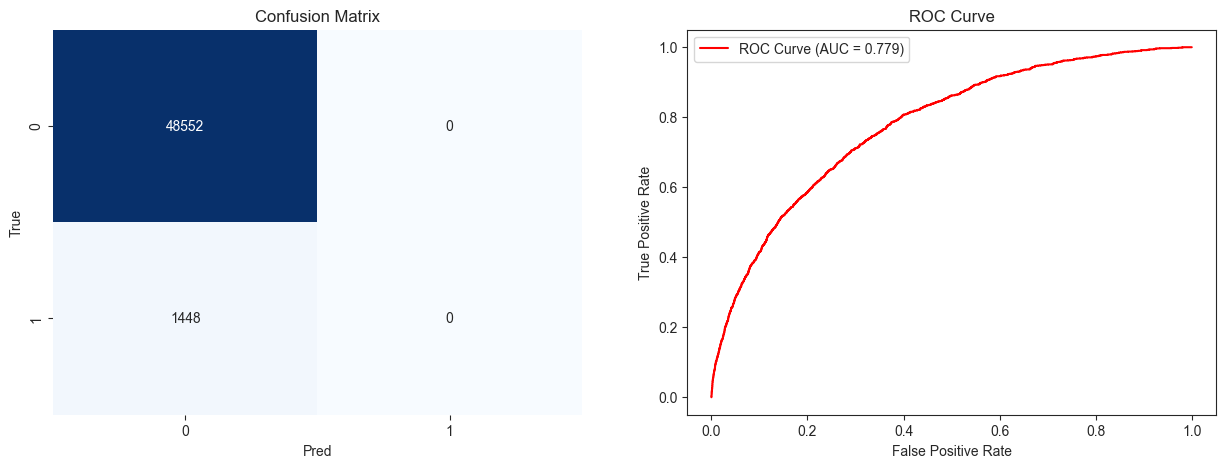

In [73]:
loaded_model.eval()

true_labels = []
predictions = []

for batch in val_dataloader:
    batch = tuple(t.to(device) for t in batch)
    input_ids, attention_mask, _rel_pos_sentences, _len_sentence_logs, labels = batch

    with torch.no_grad():
        outputs = loaded_model(input_ids, attention_mask, _rel_pos_sentences, _len_sentence_logs, labels=None)

    logits = outputs["logits"]
    logits = logits.detach().cpu().numpy()
    predictions.append(logits)

    labels = labels.to("cpu").numpy()
    true_labels.append(labels)

val_y_true = []
val_y_pred = []
val_y_score = []

for i in range(len(predictions)):
    val_y_true.extend(list(true_labels[i]))
    val_y_pred.extend(((torch.sigmoid(torch.Tensor(predictions[i])) > 0.5) * 1).view(-1).tolist())
    val_y_score.extend(torch.sigmoid(torch.Tensor(predictions[i])).view(-1).tolist())

# Accuracy
print(f"Accuracy: {metrics.accuracy_score(y_true=val_y_true, y_pred=val_y_pred)}\n")

# Classification report
print(metrics.classification_report(y_true=val_y_true, y_pred=val_y_pred))

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Confusion matrix
cm = metrics.confusion_matrix(y_true=val_y_true, y_pred=val_y_pred)
sns.heatmap(cm, annot=True, fmt="d", ax=ax1, cmap=plt.cm.Blues, cbar=False)
ax1.set(xlabel="Pred", ylabel="True", xticklabels=[0, 1], yticklabels=[0, 1], title="Confusion Matrix")

# ROC curve/AUC score
fpr, tpr, thresholds = metrics.roc_curve(y_true=val_y_true, y_score=val_y_score, pos_label=1)
auc_score = metrics.roc_auc_score(y_true=val_y_true, y_score=val_y_score)
ax2.plot(fpr, tpr, color="red", label=f"ROC Curve (AUC = {round(auc_score, 3)})")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve")
ax2.legend(loc="best")

Accuracy: 0.9715

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     48575
           1       0.00      0.00      0.00      1425

    accuracy                           0.97     50000
   macro avg       0.49      0.50      0.49     50000
weighted avg       0.94      0.97      0.96     50000



c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\yahia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



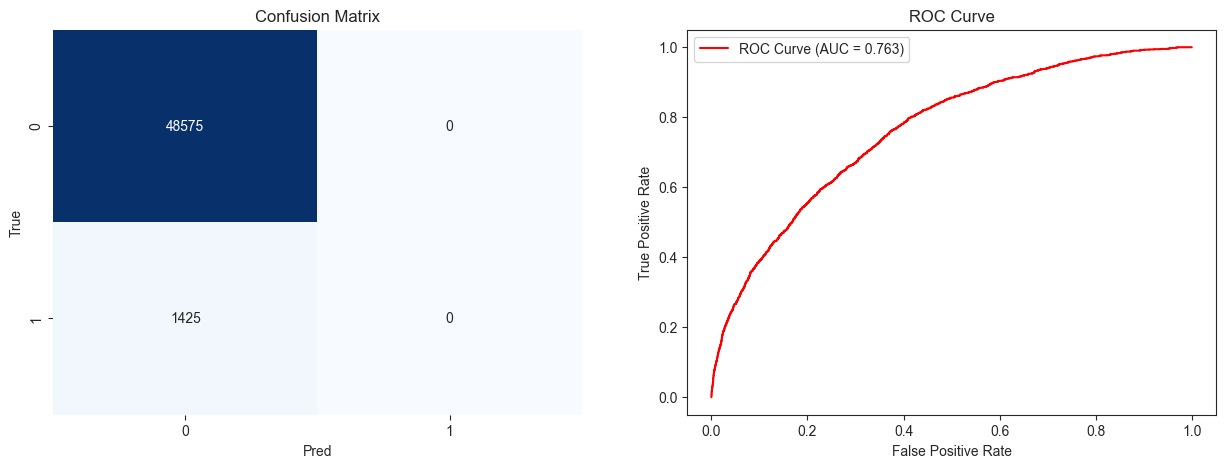

In [74]:
loaded_model.eval()

true_labels = []
predictions = []

for batch in test_dataloader:
    batch = tuple(t.to(device) for t in batch)
    input_ids, attention_mask, _rel_pos_sentences, _len_sentence_logs, labels = batch

    with torch.no_grad():
        outputs = loaded_model(input_ids, attention_mask, _rel_pos_sentences, _len_sentence_logs, labels=None)

    logits = outputs["logits"]
    logits = logits.detach().cpu().numpy()
    predictions.append(logits)

    labels = labels.to("cpu").numpy()
    true_labels.append(labels)

test_y_true = []
test_y_pred = []
test_y_score = []

for i in range(len(predictions)):
    test_y_true.extend(list(true_labels[i]))
    test_y_pred.extend(((torch.sigmoid(torch.Tensor(predictions[i])) > 0.5) * 1).view(-1).tolist())
    test_y_score.extend(torch.sigmoid(torch.Tensor(predictions[i])).view(-1).tolist())

# Accuracy
print(f"Accuracy: {metrics.accuracy_score(y_true=test_y_true, y_pred=test_y_pred)}\n")

# Classification report
print(metrics.classification_report(y_true=test_y_true, y_pred=test_y_pred))

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Confusion matrix
cm = metrics.confusion_matrix(y_true=test_y_true, y_pred=test_y_pred)
sns.heatmap(cm, annot=True, fmt="d", ax=ax1, cmap=plt.cm.Blues, cbar=False)
ax1.set(xlabel="Pred", ylabel="True", xticklabels=[0, 1], yticklabels=[0, 1], title="Confusion Matrix")

# ROC curve/AUC score
fpr, tpr, thresholds = metrics.roc_curve(y_true=test_y_true, y_score=test_y_score, pos_label=1)
auc_score = metrics.roc_auc_score(y_true=test_y_true, y_score=test_y_score)
ax2.plot(fpr, tpr, color="red", label=f"ROC Curve (AUC = {round(auc_score, 3)})")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve")
ax2.legend(loc="best")

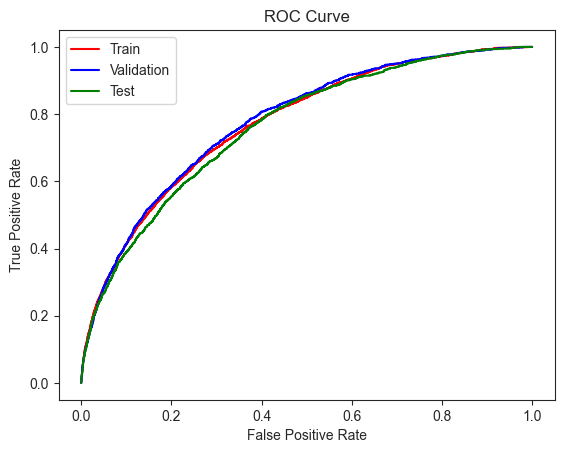

In [75]:
# Combined ROC curve for train/val/test datasets

fpr, tpr, thresholds = metrics.roc_curve(y_true=train_y_true, y_score=train_y_score, pos_label=1)
plt.plot(fpr, tpr, color="red", label=f"Train")

fpr, tpr, thresholds = metrics.roc_curve(y_true=val_y_true, y_score=val_y_score, pos_label=1)
plt.plot(fpr, tpr, color="blue", label=f"Validation")

fpr, tpr, thresholds = metrics.roc_curve(y_true=test_y_true, y_score=test_y_score, pos_label=1)
plt.plot(fpr, tpr, color="green", label=f"Test")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="best")